In [80]:

import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
from statistics import mode, median, mean, pstdev
import numpy as np
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

In [81]:
PR_metrics_path = "PR_Metrics"
dagger_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_dagger.json")
eureka_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_eureka.json")
gson_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_gson.json")
guava_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_guava.json")
guice_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_guice.json")
hystrix_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_Hystrix.json")
jabref_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_jabref.json")
mockito_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_mockito.json")
spring_boot_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_spring-boot.json")
spring_security_path = os.path.join(PR_metrics_path, "PRemo_CK.Merged_spring-security.json")
all_projects = os.path.join(PR_metrics_path,"extracted_dataset.json")

In [82]:
def add_metadata_values(pr : dict, df_data : dict) :
    state = pr['PR_state']
    is_merged = pr['PR_is_merged']
    
    if is_merged and state == "closed" :
        state = 1
    elif state == "open" :
        state = 0
    elif not(is_merged) and state == "closed" :
        state = -1
    
    
    adds = pr['PR_additions']
    dels = pr['PR_deletions']
    changed_files = pr['PR_changed_files']
    changed_classes = pr['PR_modified_class_files']
    nb_comments = pr['PR_nb_comments']

    df_data['PR_state'].append(state)
    df_data['lines_added'].append(adds)
    df_data['lines_removed'].append(dels)
    df_data['modified_files'].append(changed_files)
    df_data['modified_classes'].append(changed_classes)
    df_data['PR_nb_comments'].append(nb_comments)
    
    return df_data
    
    
def add_comments_sentiment(pr : dict, df_data : dict) :
    valence_list = []
    valences = pr["valences"]  
    
    for val_dict in valences :
        sentiment = val_dict["Sentiment"]
        
        if sentiment == "Positive" :
           sentiment = 1
        elif sentiment == "Negative" :
            sentiment = -1
        elif sentiment == "Neutral" :
            sentiment = 0
        
        valence_list.append(sentiment)
    
    
    sentiment_mode = mode(valence_list)
    sentiment_median = median(valence_list)
    sentiment_mean = mean(valence_list)
    sentiment_stdev = pstdev(valence_list)
    df_data["Polarity_mode"].append(sentiment_mode)
    df_data["Polarity_median"].append(sentiment_median)
    df_data["Polarity_mean"].append(sentiment_mean)
    df_data["Polarity_stdev"].append(sentiment_stdev)
    return df_data

In [83]:
def get_comments_per_type(filename) :
    with open(filename, 'r', encoding='utf8') as f :
        file_data = json.load(f)
    
    pos_counter = 0
    neg_counter = 0
    neu_counter = 0
    
    for entry in range(len(file_data)) :
        pr = file_data[entry]

        valences = pr["valences"]  
        

        for val_dict in valences :
            sentiment = val_dict["Sentiment"]

            if sentiment == "Positive" :
               pos_counter += 1
            elif sentiment == "Negative" :
                neg_counter += 1
            elif sentiment == "Neutral" :
                neu_counter +=1

    return pos_counter, neg_counter, neu_counter

In [84]:
def get_df_data(filename) :
    
    df_data = {
    "Polarity_median" : [], # 1 = positive, 0 = neutral, -1 = negative 
    "Polarity_mean" : [],
    "Polarity_mode" : [],  # same
    "Polarity_stdev" : [],
    "PR_nb_comments" : [],
    "PR_state" : [], # closed = 0, open = -1
    "lines_added" : [],
    "lines_removed" : [],
    "modified_files" : [],
    "modified_classes" : [],
       
    "class_loc" : [], #median
    "class_cboModified" : [], #median
    "class_wmc" : [], # median
    "class_lcom*" : [], #median
    "total_methods_qtt" : [], #median
    #"static_methods_qtt" : [],
    #"public_methods_qtt" : [],
    #"private_methods_qtt" : [],
    #"protected_methods_qtt" : [],
    #"default_methods_qtt" : [],
    #"visible_methods_qtt" : [],
    #"abstract_methods_qtt" : [],
    #"final_methods_qtt" : [],
    #"synchronized_methods_qtt" : [],
    
    "method_loc" : [],
    "method_cboModified" : [],
    "method_wmc" : [],
    "parameters_qtt" : []
    }
    
    
    with open(filename, 'r', encoding='utf8') as f :
        file_data = json.load(f)
    
    for entry in range(len(file_data)) :
        class_loc_list = []
        class_cboModified_list = []
        class_wmc_list = []
        class_lcom_list = []
        total_methods_list = []
        public_methods = []
        static_methods = []
        private_methods = []
        protected_methods = []
        default_methods = []
        visible_methods = []
        abstract_methods = []   
        final_methods = []
        synchrnonized_methods = []
        
        method_loc_list = []
        method_cboModified_list = []
        method_wmc_list = []
        parameters_qtt_list = []    
        
        
        pr = file_data[entry]

        df_data = add_metadata_values(pr["Meta"], df_data)

        df_data = add_comments_sentiment(pr, df_data)
        
        diff = pr["Diff"] 
        for _class in diff.keys() :
            class_dict = diff[_class]
            
            for key in class_dict.keys() :
            
                val = class_dict[key]
            
                if isinstance(val, (int, float)) : #class metric

                    match key:
                        case "loc" :
                            class_loc_list.append(val)
                            
                        case "wmc":
                            class_wmc_list.append(val)

                        case "cboModified" :
                            class_cboModified_list.append(val)

                        case "lcom*" :
                            class_lcom_list.append(val)

                        case "totalMethodsQty" :
                            total_methods_list.append(val)

                        case "staticMethodsQty" :
                            static_methods.append(val)

                        case "publicMethodsQty" :
                            public_methods.append(val)

                        case "privateMethodsQty" :
                            private_methods.append(val)

                        case "protectedMethodsQty" :
                            protected_methods.append(val)

                        case "defaultMethodsQty" :
                            default_methods.append(val)

                        case "visibleMethodsQty" :
                            visible_methods.append(val)

                        case "abstractMethodsQty" :
                            abstract_methods.append(val)

                        case "finalMethodsQty" :
                            final_methods.append(val)

                        case "synchronizedMethodsQty" :
                            synchrnonized_methods.append(val)                    

                elif isinstance(val, dict) : #methods
                    method_loc_list.append(val['loc'])
                    method_cboModified_list.append(val['cboModified'])
                    method_wmc_list.append(val['wmc'])
                    parameters_qtt_list.append(val['parametersQty'])
        
        #adding medians to df_data
        df_data["class_loc"].append(median(class_loc_list))
        df_data["class_cboModified"].append(median(class_cboModified_list))
        df_data["class_wmc"].append(median(class_wmc_list))
        df_data["class_lcom*"].append(median(class_lcom_list))
        df_data["total_methods_qtt"].append(median(total_methods_list))
        #df_data["static_methods_qtt"].append(median(static_methods))
        #df_data["public_methods_qtt"].append(median(public_methods))
        #df_data["private_methods_qtt"].append(median(private_methods))                
        #df_data["protected_methods_qtt"].append(median(protected_methods))
        #df_data["default_methods_qtt"].append(median(default_methods))
        #df_data["visible_methods_qtt"].append(median(visible_methods))
        #df_data["abstract_methods_qtt"].append(median(abstract_methods))
        #df_data["final_methods_qtt"].append(median(final_methods))
        #df_data["synchronized_methods_qtt"].append(median(synchrnonized_methods))
        
        #handle cases where no methods where modified in a PR -> insert default values
        if len(method_loc_list) < 1 : 
            df_data["method_loc"].append(np.nan)  
        else : 
            df_data["method_loc"].append(median(method_loc_list))
        

        if len(method_cboModified_list) < 1 :
            df_data["method_cboModified"].append(np.nan)
        else:
            df_data["method_cboModified"].append(median(method_cboModified_list))
        
        
        if len(method_wmc_list) < 1 :
            df_data["method_wmc"].append(np.nan)
        else :
            df_data["method_wmc"].append(median(method_wmc_list))
        
        
        if len(parameters_qtt_list) < 1 :
            df_data['parameters_qtt'].append(np.nan)
        else :
            df_data["parameters_qtt"].append(median(parameters_qtt_list))
     
        
    return df_data

In [85]:
from scipy.stats import shapiro
from pprint import pprint

In [86]:
def get_project_name(path : str) :
 splited_with_ext = path.split('_')[3]
 without_ext = splited_with_ext.replace('.json', "")
 
 return without_ext

In [87]:
def normalize_df(df) :
    scaled = df.copy()

    for column in scaled.columns:
        if column not in ["Polarity_mode", "Polarity_mean", "Polarity_median", "PR_state"] :
            scaled[column] = (scaled[column] - scaled[column].min()) / (scaled[column].max() - scaled[column].min())

    return scaled

    

In [88]:
def check_data_distribution(df_data) :
    data_asArray = list(df_data.items())
    p_value_list = []
    for key in df_data.keys() :
         row_values = df_data[key]
         p_value_list.append(float(shapiro(row_values).pvalue))
    print(p_value_list)
    if not any(float(p_val) > 0.05 for p_val in p_value_list) :
        return "spearman"
    
    else : 
        print('normal distribution is SUGGESTED, but no waranty, returning pearson parameter for correlation matrix')
        return "pearson"
    

In [89]:
def dt_routine(df, y, test_size,criterion, max_depth, min_sample_split, min_sample_leaf, max_leaf_nodes, ccp_alpha) :
        features = ["PR_nb_comments", "PR_state", "lines_added", "lines_removed", "modified_files", "modified_classes",
            "class_loc", "class_cboModified", "class_wmc", "class_lcom*", "total_methods_qtt", "method_loc",
            "method_cboModified", "method_wmc", "parameters_qtt"]

        X = df[features]
        y = y
        y = [int(x) for x in y]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
        dt = DecisionTreeClassifier(criterion =criterion, max_depth = max_depth, min_samples_split = min_sample_split, min_samples_leaf = min_sample_leaf, max_leaf_nodes = max_leaf_nodes,
                                   random_state = 42, ccp_alpha=ccp_alpha)
        
        dt.fit(X_train, y_train)
        
        plot_tree(dt, feature_names=features, class_names=['Positive', 'Negative', 'Neutral'] ,filled=True, fontsize=5)
        y_pred = dt.predict(X_test)
        print("Précision du modèle (train) :", dt.score(X_train, y_train))
        print("Précision du modèle (test) :", metrics.accuracy_score(y_test, y_pred))

# Dagger PR corr Matrix

[0.00013097817774592862, 0.020715217550184184, 0.00013097817774592862, 0.2827650592503465, 0.42551331588063185, 1.0, 0.3798860094722079, 0.3459629113937357, 0.03915209062951175, 0.06810199529526134, 0.14373316291870256, 0.4211496535161197, 0.31403955614403806, 0.00013097817774592862, 0.31403955614403806, nan, nan, nan, nan]
normal distribution is SUGGESTED, but no waranty, returning pearson parameter for correlation matrix
Number of entries for project dagger : 5


/Users/xdevroey/git/SentiDex-Replication-Package/venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


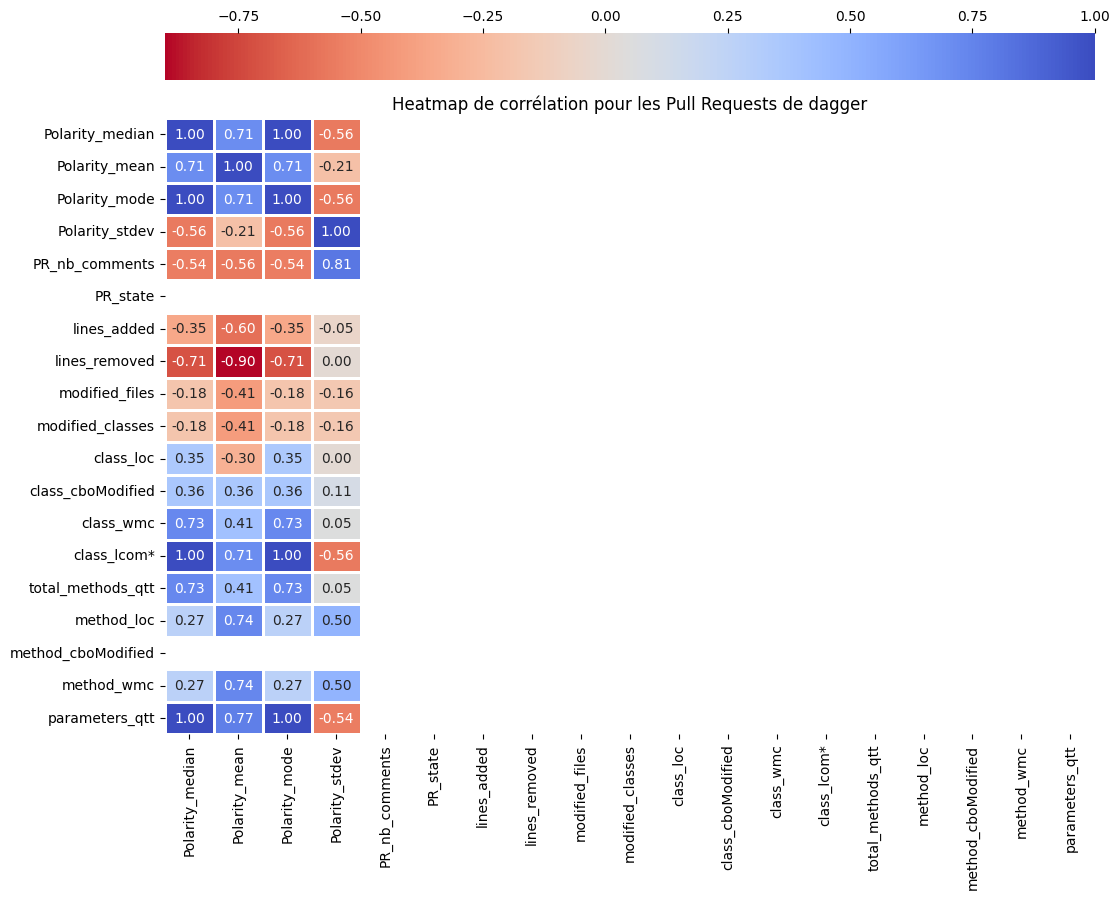

Précision du modèle (train) : 0.75
Précision du modèle (test) : 1.0


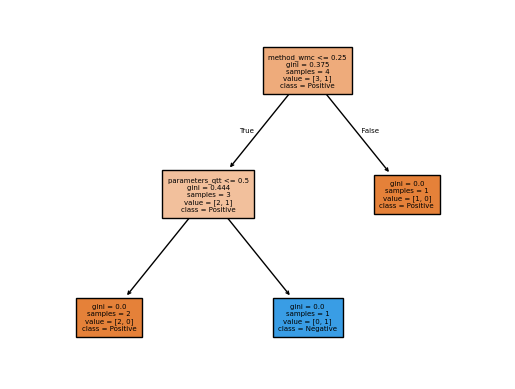

In [90]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(dagger_path)
    
    columns = df_data.keys()
    
    project_name = get_project_name(dagger_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    matrix = scaled.corr(method="spearman")
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm_r", mask = mask,fmt=".2f", linewidths=1, cbar_kws=dict(use_gridspec=False,location="top"))
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_mode'],test_size=0.2,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.02)
     

# Eureka PR corr Matrix

[0.00011599257670767245, 0.013215283560503987, 0.00011599257670767245, 0.002292076966572221, 0.00462357161530668, 4.0251302202538165e-06, 3.757268333487039e-05, 1.5006227917104704e-05, 0.001708768671509214, 0.001756625955524222, 0.0001597886262758955, 0.0002107676647098467, 0.004181190460690553, 1.1018128201991136e-06, 6.0520573527481864e-05, 0.014290886870984221, 5.67952850403302e-06, 0.00023842556629682972, 1.0]
normal distribution is SUGGESTED, but no waranty, returning pearson parameter for correlation matrix
Number of entries for project eureka : 13


/Users/xdevroey/git/SentiDex-Replication-Package/venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


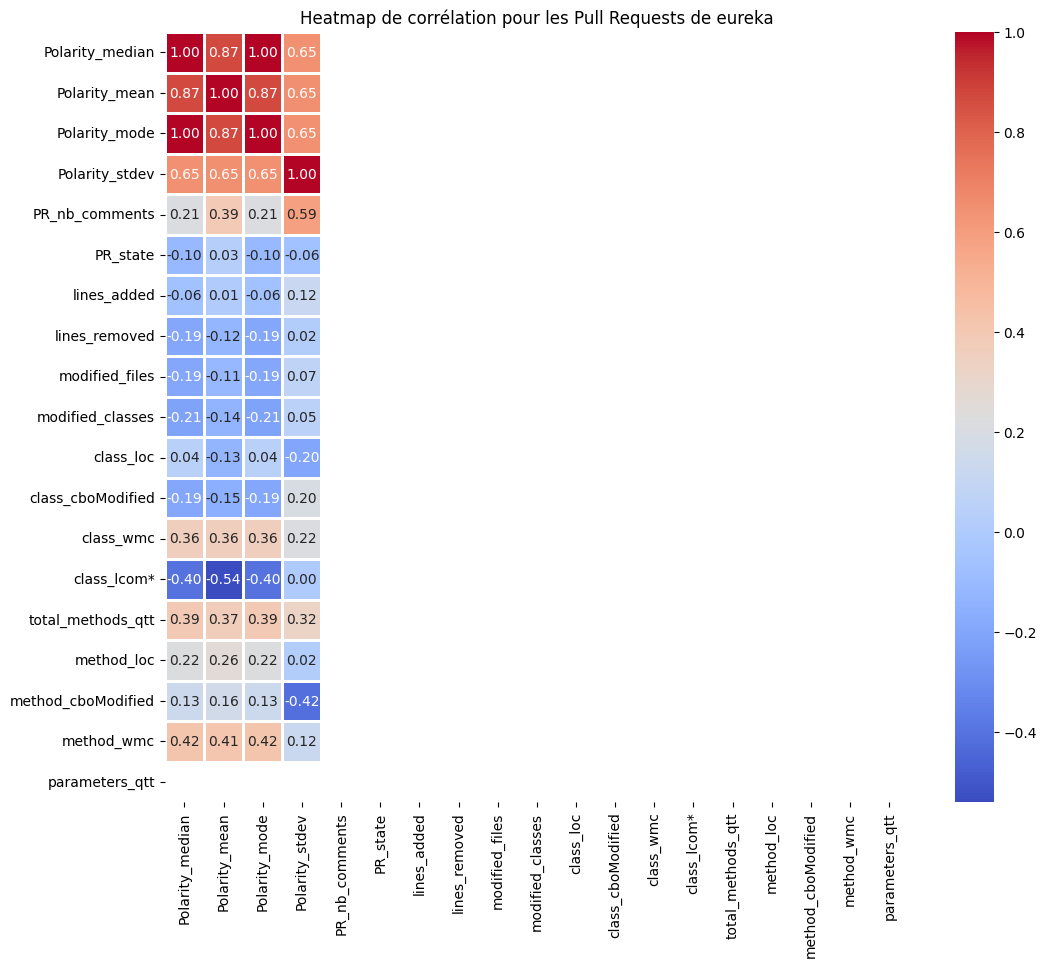

Précision du modèle (train) : 1.0
Précision du modèle (test) : 0.0


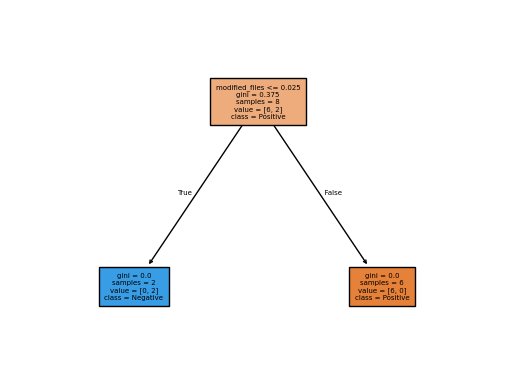

In [91]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(eureka_path)
    
    project_name = get_project_name(eureka_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    
    matrix = scaled.corr(method="spearman")
    
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    
    
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", mask=mask,fmt=".2f", linewidths=1)
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_median'], test_size=0.33,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.03)

# Gson PR corr Matrix

[4.6745539116575915e-07, 0.007601599396107046, 1.5857115162006376e-07, 0.0008768699717442787, 4.875916848638839e-05, 1.5784261286633814e-07, 7.555132031422282e-11, 1.2597466905080788e-11, 3.603734203090899e-10, 8.991222851037023e-10, 3.979967691406476e-06, 7.379166353500366e-09, 8.349955927922734e-07, 5.4311071659403784e-11, 1.955064801078099e-06, nan, nan, nan, nan]
Number of entries for project gson : 31


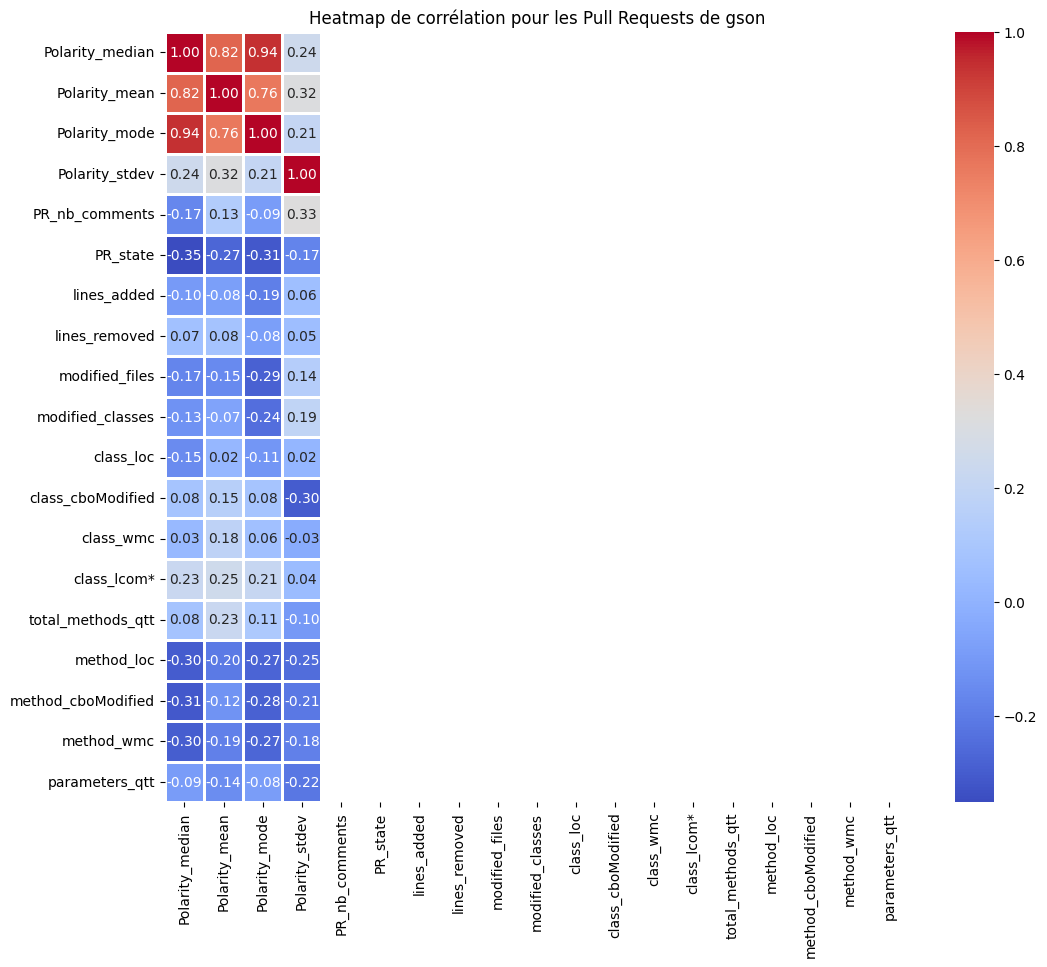

Précision du modèle (train) : 1.0
Précision du modèle (test) : 0.7272727272727273


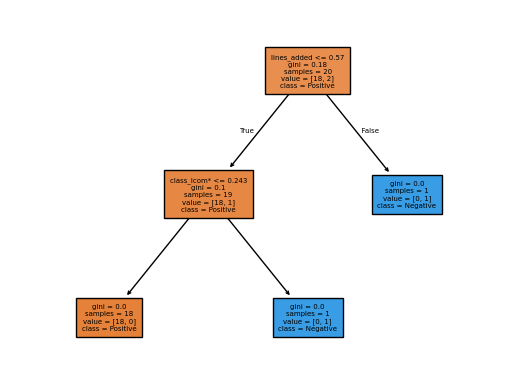

In [92]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(gson_path)
    
    project_name = get_project_name(gson_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    matrix = scaled.corr(method="spearman")
    
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", mask=mask, fmt=".2f", linewidths=1)
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_median'], test_size=0.33,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.01)

# Guava PR corr Matrix

[5.9043629922207444e-05, 0.3136205889389484, 1.5645428836708182e-06, 0.00014662422383060177, 3.837851191271624e-05, 5.802385770751725e-10, 2.085601327609387e-11, 1.2217818472567343e-11, 4.122234532913333e-12, 2.6598861372385948e-11, 4.141850427214042e-08, 1.0058445530363618e-09, 5.203702430862404e-08, 1.1426945362347792e-11, 5.132537174540558e-09, nan, nan, nan, nan]
normal distribution is SUGGESTED, but no waranty, returning pearson parameter for correlation matrix
Number of entries for project guava : 32


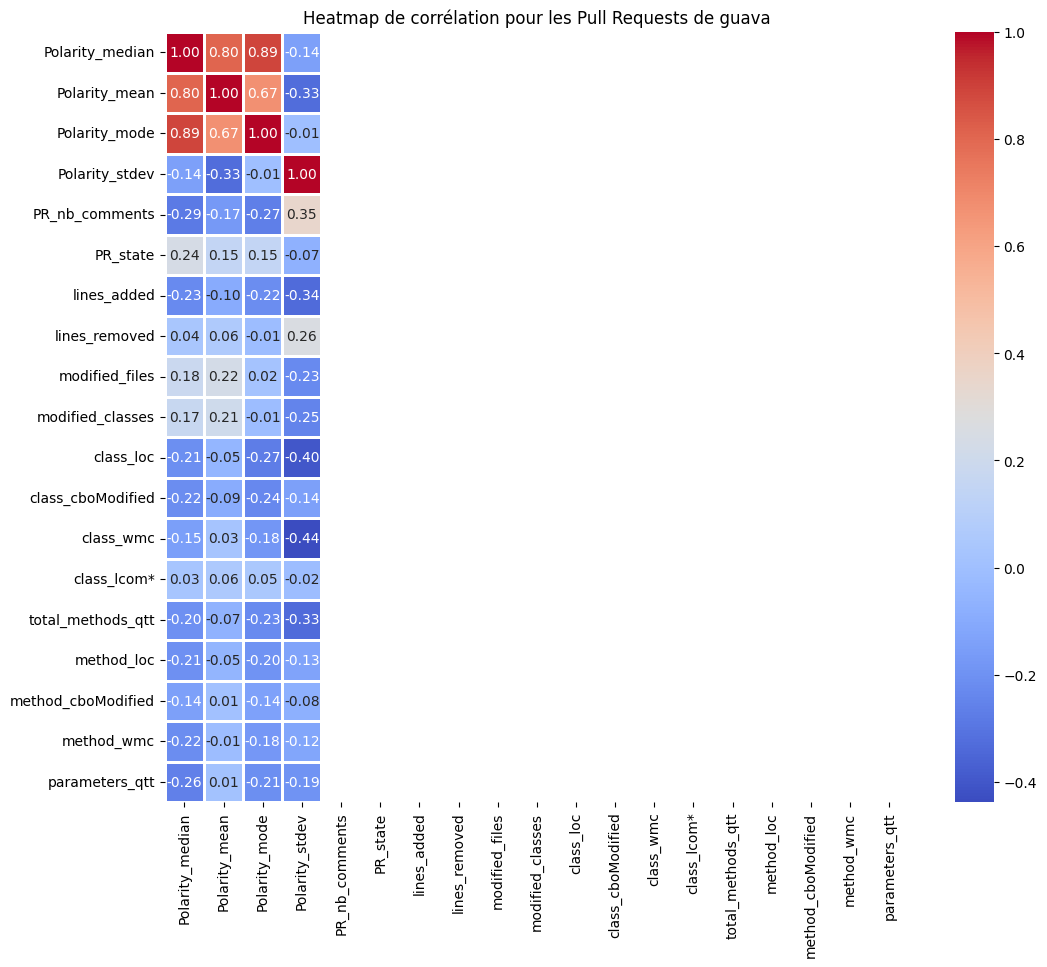

Précision du modèle (train) : 0.9523809523809523
Précision du modèle (test) : 0.6363636363636364


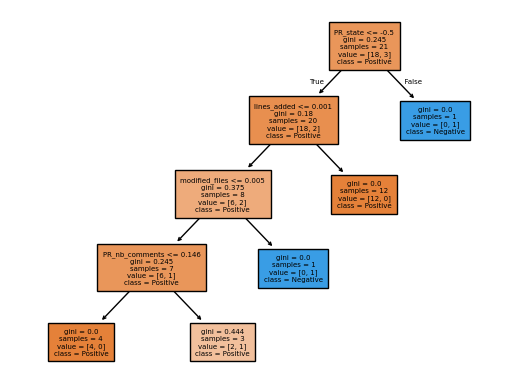

In [93]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(guava_path)
    
    project_name = get_project_name(guava_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    matrix = scaled.corr(method="spearman")
    
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    
    
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", mask=mask, fmt=".2f", linewidths=1)
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.xticks()
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_median'], test_size=0.33,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.01)

# Guice PR corr Matrix

[1.686024701044308e-05, 0.07542809563746293, 0.0001525914707021745, 0.11667815460956571, 0.355736546528525, 3.2174928627621843e-07, 1.5171187181605072e-06, 7.620247102571174e-06, 7.4590482365703e-05, 1.3071370188599844e-05, 0.09347100104053883, 0.011624038777438414, 0.09251138315476864, 5.660684753999633e-06, 0.869331466035897, nan, nan, nan, nan]
normal distribution is SUGGESTED, but no waranty, returning pearson parameter for correlation matrix
Number of entries for project guice : 9


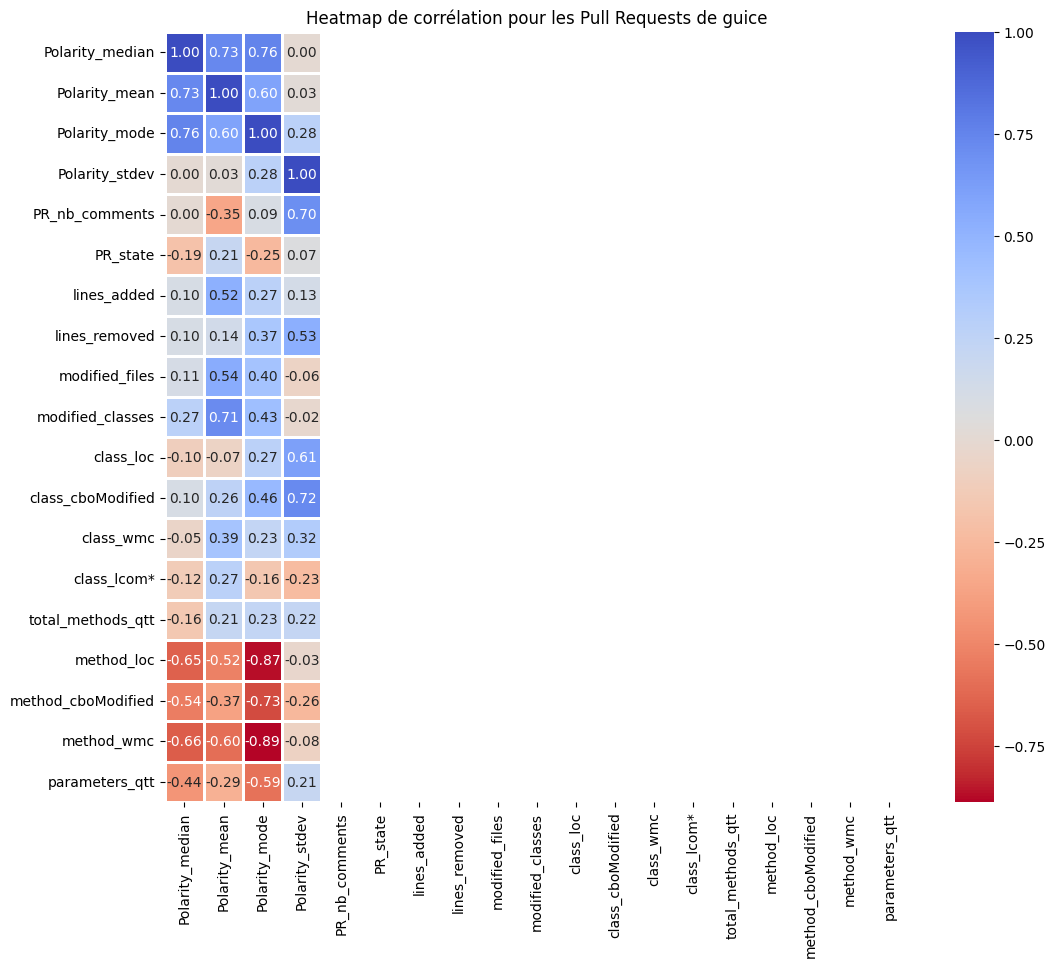

Précision du modèle (train) : 1.0
Précision du modèle (test) : 1.0


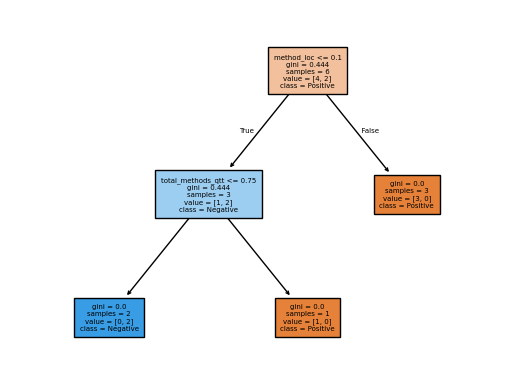

In [94]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(guice_path)
    
    project_name = get_project_name(guice_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    matrix = scaled.corr(method="spearman")
    
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm_r", mask= mask, fmt=".2f", linewidths=1)
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_median'], test_size=0.33,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.01)

# Hystrix PR corr Matrix

[0.0051808145191420945, 0.06139660670030614, 0.0051808145191420945, 0.022770360548755853, 0.01300088572532034, 0.00571063477775866, 0.008581701989915539, 1.5218011072919781e-05, 0.01705128832107744, 0.02421167621692519, 0.24093660771491046, 0.0001936632459983576, 0.005791420716174214, 1.0498167731702636e-06, 0.013065312155635363, nan, nan, nan, nan]
normal distribution is SUGGESTED, but no waranty, returning pearson parameter for correlation matrix
Number of entries for project Hystrix : 8


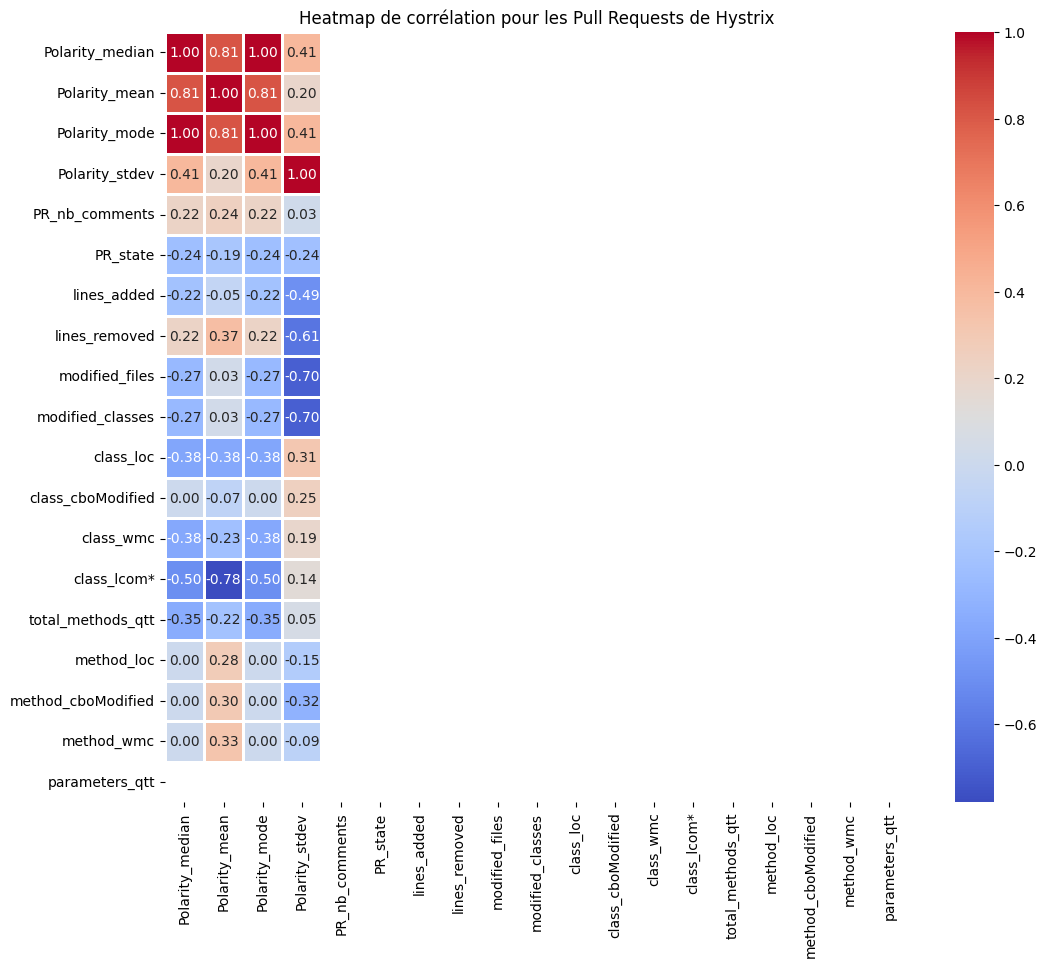

Précision du modèle (train) : 1.0
Précision du modèle (test) : 0.6666666666666666


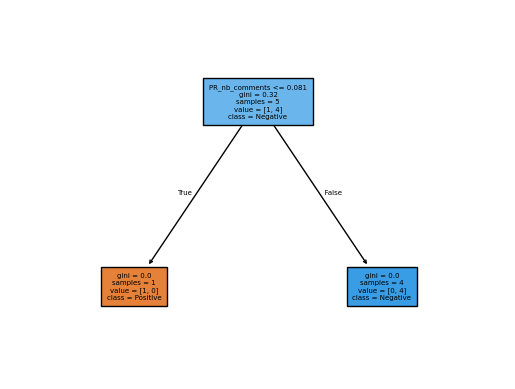

In [95]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(hystrix_path)
    
    project_name = get_project_name(hystrix_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    matrix = scaled.corr(method="spearman")
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", mask=mask, linewidths=1)
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_median'], test_size=0.33,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.01)

# Jabref PR corr Matrix

[2.2329416251104864e-07, 0.0024414992127148216, 2.5730084866876802e-09, 0.003882938234477352, 0.25926146738311473, 1.1241446179646007e-07, 6.656224590974297e-07, 2.8854990607630847e-08, 1.8261690058859282e-06, 2.1797957050636633e-06, 4.7142785662403866e-06, 1.901797330130695e-05, 2.691868940710978e-05, 1.8196475156583016e-07, 5.046310377560869e-06, nan, nan, nan, nan]
normal distribution is SUGGESTED, but no waranty, returning pearson parameter for correlation matrix
Number of entries for project jabref : 23


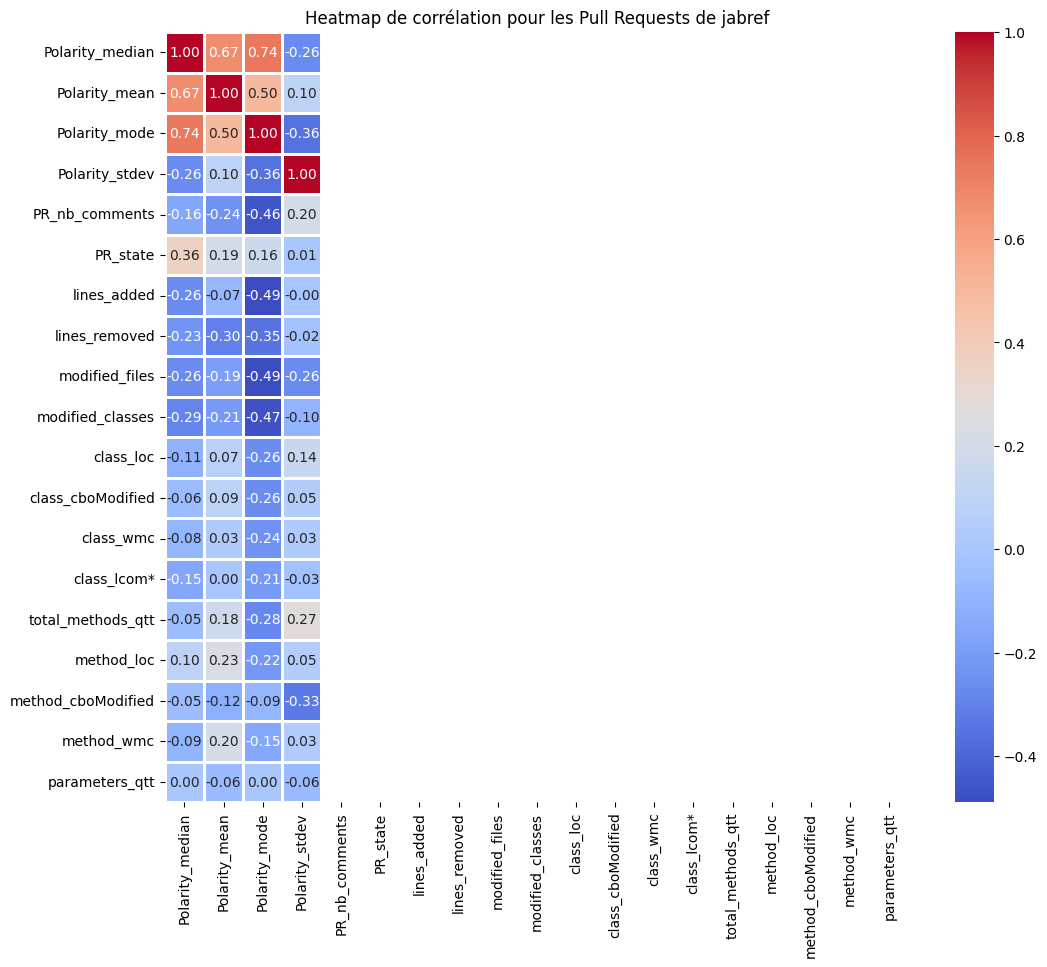

Précision du modèle (train) : 1.0
Précision du modèle (test) : 0.875


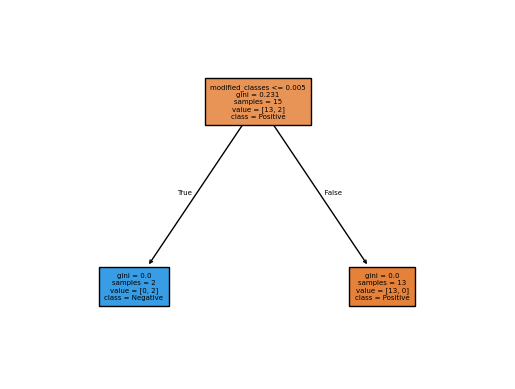

In [96]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(jabref_path)
    
    project_name = get_project_name(jabref_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    matrix = scaled.corr(method="spearman")
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", mask=mask, linewidths=1)
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_median'], test_size=0.33,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.01)

# Mockito PR coor Matrix

[4.42668363241358e-06, 0.011839816299319333, 5.124753482599145e-07, 0.0028732215651513216, 2.6388954819075895e-05, 6.882740098326267e-06, 0.00023078789207164695, 1.8941578987143674e-07, 0.0004520793940161602, 7.5088817190952e-05, 0.0006142521835490326, 0.007387500549780193, 0.00167771179520547, 1.0009308232157847e-07, 0.005960435313762979, nan, nan, nan, nan]
Number of entries for project mockito : 18


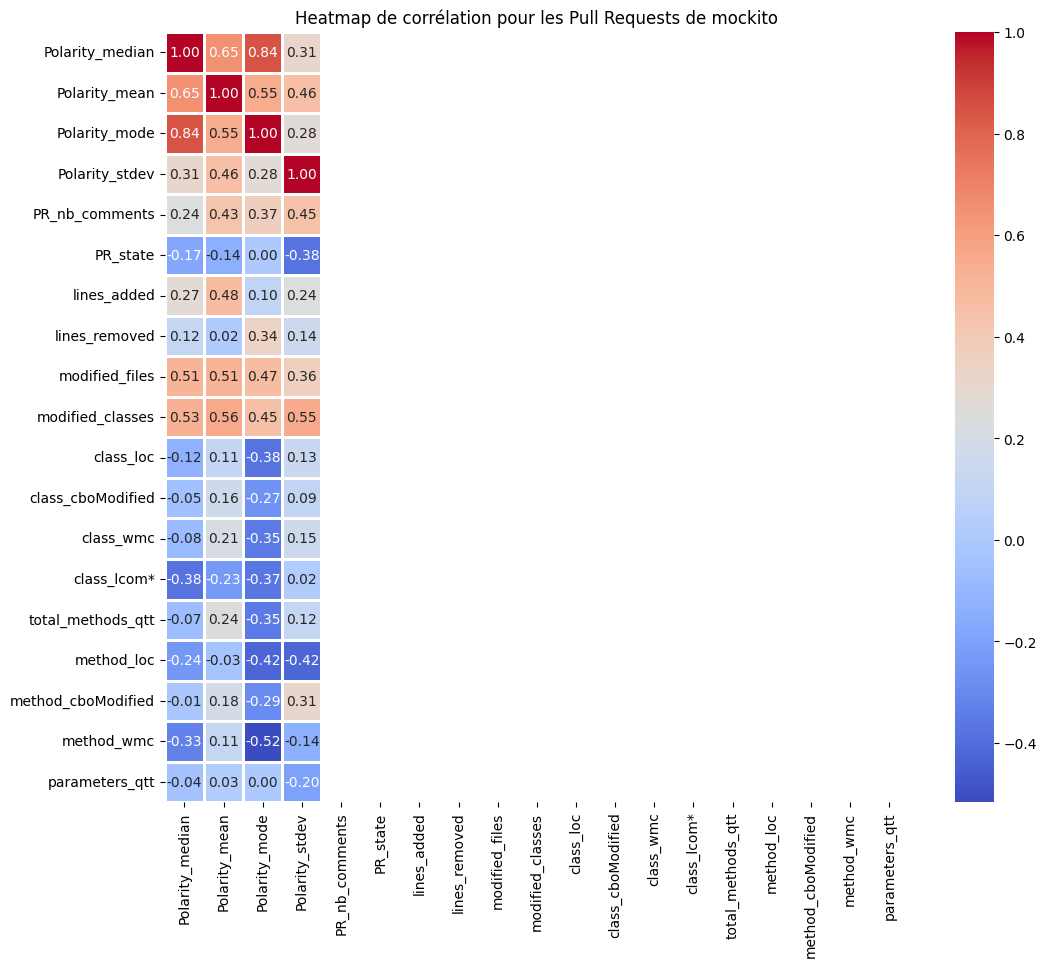

Précision du modèle (train) : 0.8333333333333334
Précision du modèle (test) : 0.6666666666666666


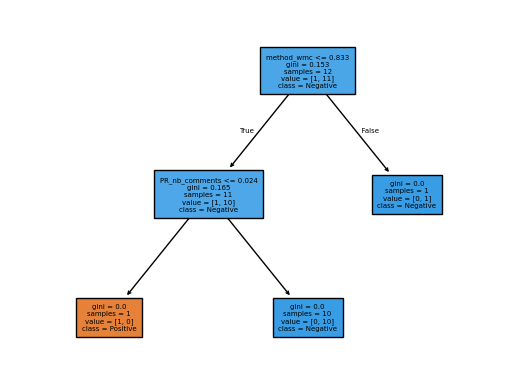

In [97]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(mockito_path)
    
    project_name = get_project_name(mockito_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    matrix = scaled.corr(method="spearman")
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", mask=mask,linewidths=1)
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_median'], test_size=0.33,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.01)

# Spring-boot PR corr Matrix

[6.146238329005055e-20, 1.3160596951858287e-08, 5.363487447939041e-22, 4.957222144039704e-14, 1.1994205614612514e-15, 1.0, 1.6344302148468507e-30, 3.7131226244836684e-30, 1.401555284610636e-30, 2.734152723960761e-26, 1.0489231998088756e-18, 2.3392217862049257e-20, 7.611059259971445e-18, 4.380635043400742e-26, 5.207153528800465e-17, nan, nan, nan, nan]
normal distribution is SUGGESTED, but no waranty, returning pearson parameter for correlation matrix
Number of entries for project spring-boot : 209


/Users/xdevroey/git/SentiDex-Replication-Package/venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


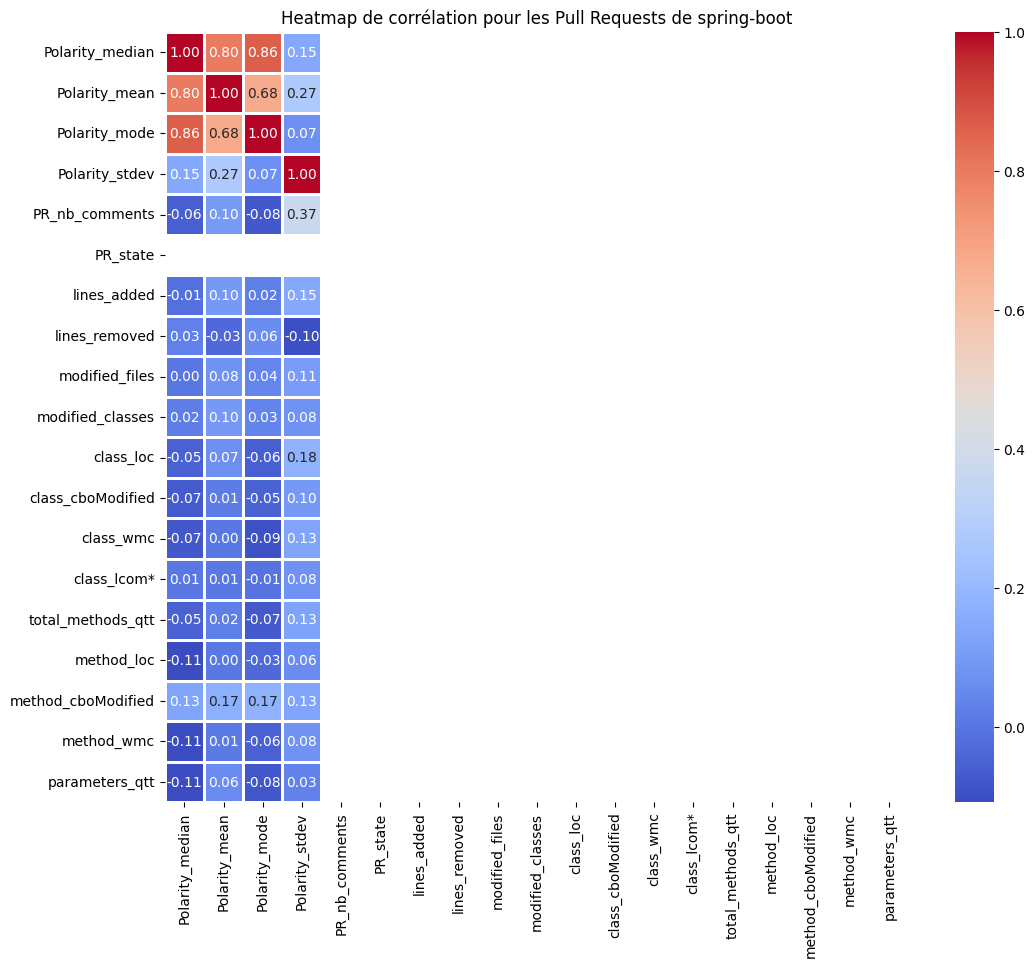

Précision du modèle (train) : 0.85
Précision du modèle (test) : 0.8695652173913043


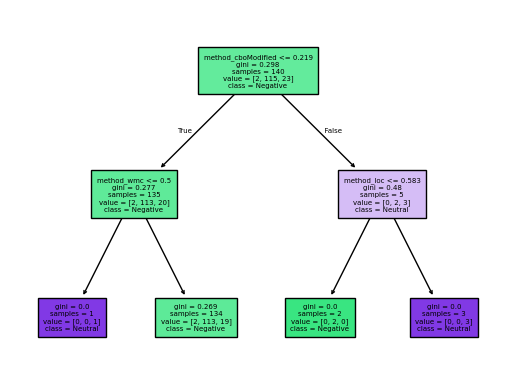

In [98]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(spring_boot_path)
    
    project_name = get_project_name(spring_boot_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    matrix = scaled.corr(method="spearman")
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", mask=mask, linewidths=1)
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_median'], test_size=0.33,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.01)
    

# Spring-security PR corr Matrix

[2.9507401052391258e-12, 2.167505294797463e-06, 1.8647915202130662e-13, 1.3571137952611966e-08, 5.0929559302288855e-12, 1.6575874378068432e-13, 7.415459132799747e-20, 5.844503410042426e-20, 6.461266596439299e-20, 2.0146735667499306e-17, 1.0288771610498253e-11, 1.0255173311410277e-14, 2.5072704255937767e-14, 9.701796339288827e-17, 2.1789083698479995e-11, nan, nan, nan, nan]
Number of entries for project spring-security : 81


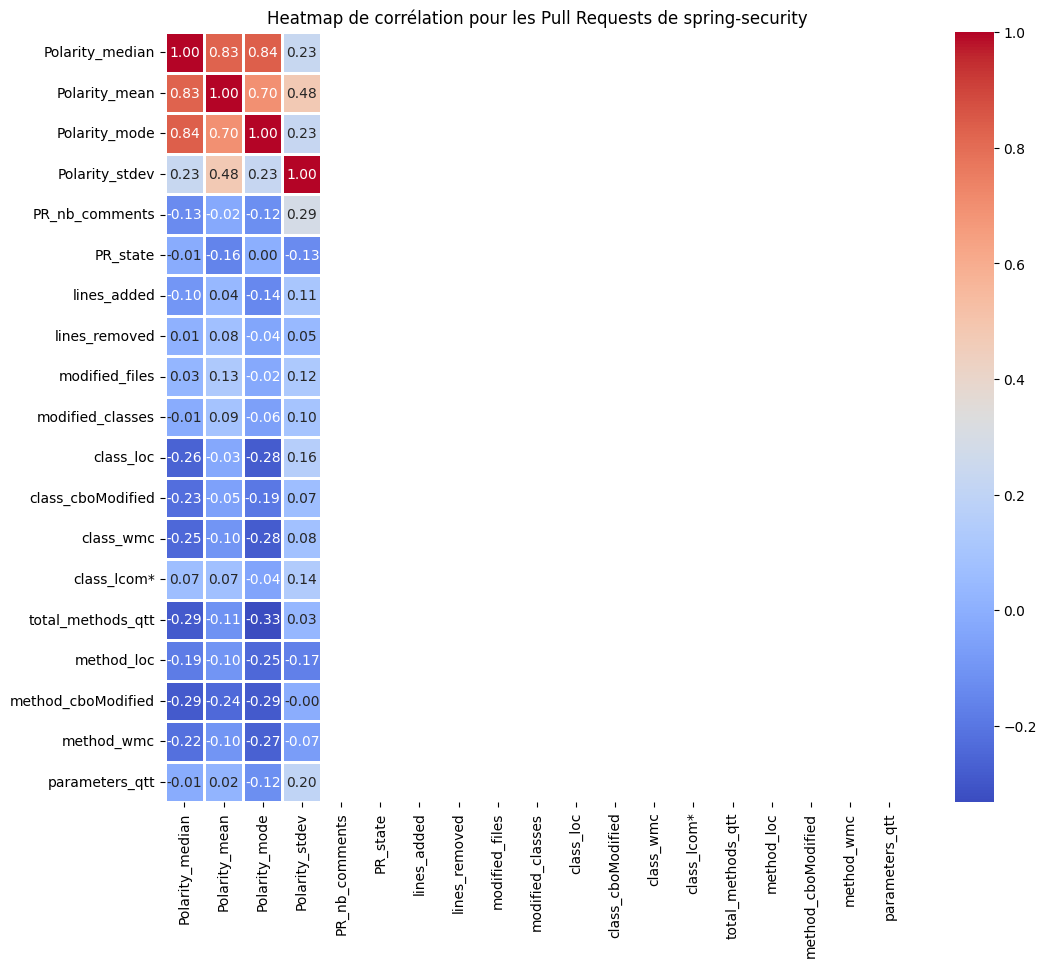

Précision du modèle (train) : 0.9444444444444444
Précision du modèle (test) : 0.7777777777777778


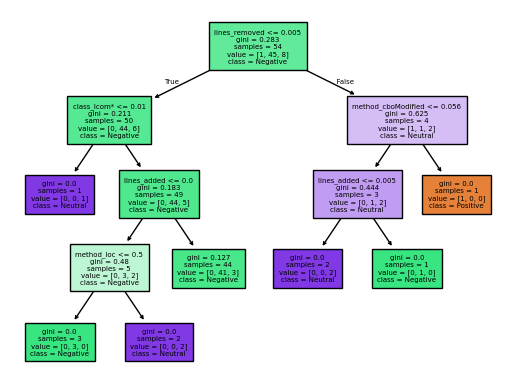

In [99]:
if __name__ == "__main__" : 
    
    df_data = get_df_data(spring_security_path)
    
    project_name = get_project_name(spring_security_path)
        
    method_type = check_data_distribution(df_data)    
        
    df = pd.DataFrame(df_data)
    
    print(f'Number of entries for project {project_name} : {len(df)}')
    
    scaled = normalize_df(df)
    
    matrix = scaled.corr(method="spearman")
    mask = np.zeros_like(matrix, dtype=bool)
    mask[:, 4:] = True
    
    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", mask=mask, linewidths=1)
    plt.title(f"Heatmap de corrélation pour les Pull Requests de {project_name}")
    plt.show()
    
    dt_routine(scaled, scaled['Polarity_median'], test_size=0.33,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf=1, max_leaf_nodes=None, ccp_alpha=0.01)

# All project Corr Matrix and DT

In [100]:
# df_data = get_df_data(all_projects)
# columns = df_data.keys()
#
#
# df = pd.DataFrame(df_data, columns=columns)
#
# #scaled = df.copy()
# #scaled = normalize_df(scaled)
# path = os.path.join(PR_metrics_path,"extracted_dataset.csv")
# #normalized = os.path.join(PR_metrics_path,"normalized_extracted_dataset.csv")
# df.to_csv(path, sep =',', encoding='utf-8', columns=columns, header=True, float_format="%.2f" ,index=True)
#scaled.to_csv(path, sep =',', encoding='utf-8', columns=columns, header=True, float_format="%.2f", index=True)

In [101]:
#if __name__ == "__main__" :
    #
    # df_data = get_df_data(all_projects)
    #
    # columns = df_data.keys()
    #
    # #project_name = get_project_name(dagger_path)
    #
    # method_type = check_data_distribution(df_data)
    #
    # df = pd.DataFrame(df_data)
    #
    # print(f'Total number of entries : {len(df)}')
    #
    # scaled = normalize_df(df)
    #
    # matrix = scaled.corr(method="pearson")
    #
    # mask = np.zeros_like(matrix, dtype=bool)
    # mask[:, 4:] = True
    #
    #
    # plt.figure(figsize=(12,10))
    # sns.heatmap(matrix, annot=True, cmap="coolwarm_r", mask= mask, fmt=".2f", linewidths=1, cbar_kws = dict(use_gridspec=False,location="top"))
    # plt.title(f"Heatmap de corrélation pour toutes les Pull Requests extraites")
    # plt.show()
    
    #dt_routine(scaled, y=scaled['Polarity_median'],test_size=0.33 ,criterion="gini", max_depth=4, min_sample_split=2, min_sample_leaf = 1, max_leaf_nodes=None, ccp_alpha=0.005)

# Répartition par projet

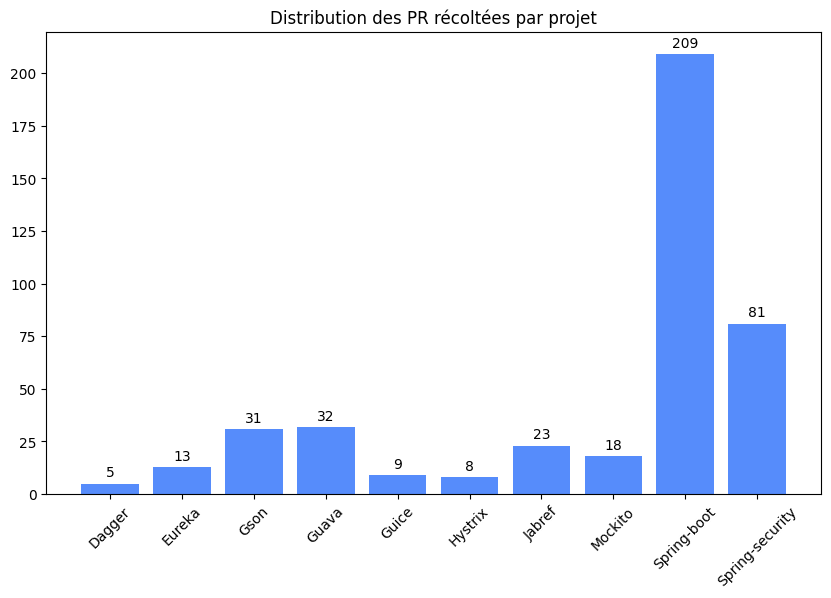

In [102]:
data = [5,13,31,32,9,8,23,18,209,81]
label = ["Dagger", "Eureka", "Gson", "Guava", "Guice", "Hystrix", "Jabref", "Mockito", "Spring-boot", "Spring-security"]

plt.figure(figsize=(10,6))
plt.bar(label, data)
plt.xticks(rotation = 45)
plt.title(f"Distribution des PR récoltées par projet")
for i in range(len(data)):
    plt.annotate(str(data[i]), xy=(label[i], data[i]), xytext=(0, 5),
                 textcoords="offset points", ha='center')
plt.show()

# Répartition des types de commentaires sur toutes les PR

In [103]:




# pos_counter, neg_counter, neu_counter = get_comments_per_type(all_projects)
# labels = ["Positif", "Négatifs", "Neutres"]
# values = [pos_counter, neg_counter, neu_counter]
# tot = pos_counter + neg_counter + neu_counter
# plt.figure(figsize=(6, 6))
#
# plt.pie(
#     values,
#     labels=labels,
#     autopct=lambda pct: f"{int(pct/100.*sum(values))} ({pct:.1f}%)",
#     startangle=90
# )
#
# plt.title(f"Répartition des types de commentaires sur l'ensemble des PR (Total : {tot}) ")
#
# plt.axis("equal")
# plt.show()


# Loading CSV

In [149]:
path = os.path.join(PR_metrics_path,"extracted_dataset.csv")
df = pd.read_csv(path)


# Nombre de PR par PR_state

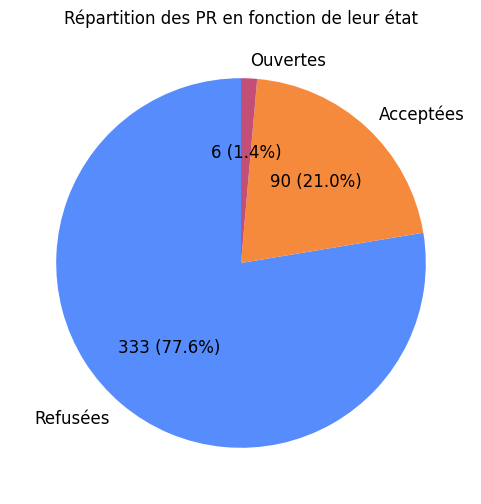

In [105]:


counts = df["PR_state"].value_counts()

plt.figure(figsize=(6, 6))

def format_label(pct, all_vals):
    absolute = int(round(pct/100. * sum(all_vals)))
    return f"{absolute} ({pct:.1f}%)"

plt.pie(
    counts.values,
    labels=['Refusées', 'Acceptées', 'Ouvertes'],
    autopct=lambda pct: format_label(pct, counts.values),
    startangle=90
)

plt.setp(plt.gca().texts, fontsize=12)        # labels

plt.title("Répartition des PR en fonction de leur état")

plt.show()





# Anova sur PR_state

F-statistic: 0.1586578162408234
p-value: 0.8533079564566307


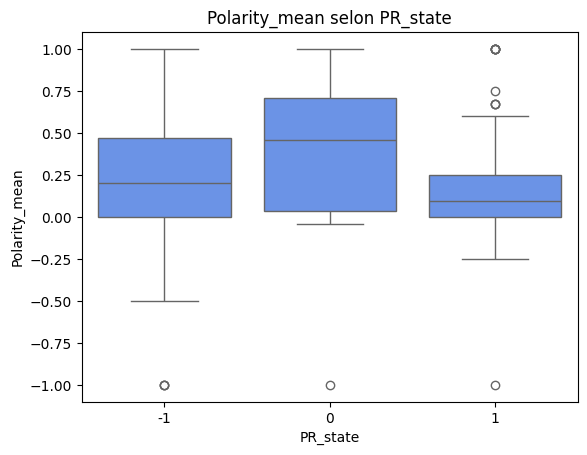

In [134]:

group_closed = df[df["PR_state"] == -1]["Polarity_mean"].dropna()
group_open = df[df["PR_state"] != 0]["Polarity_mean"].dropna()
group_merged = df[df["PR_state"] != 1]["Polarity_mean"].dropna()

F_stat, p_value = f_oneway(group_closed, group_open, group_merged)

print("F-statistic:", F_stat)
print("p-value:", p_value)


sns.boxplot(x="PR_state", y="Polarity_mean", data=df)

plt.title("Polarity_mean selon PR_state")
plt.xlabel("PR_state")
plt.ylabel("Polarity_mean")

plt.show()



# Classification en 3 groupes sur base de la valeur médiane de la polarité

In [150]:

# Définir les 3 groupes
df_negative = df[df["Polarity_median"] < -0.25]

df_neutral = df[
    (df["Polarity_median"] >= -0.25) &
    (df["Polarity_median"] <= 0.25)
]

df_positive = df[df["Polarity_median"] > 0.25]


print(len(df))
print("Negative:", len(df_negative))
print("Neutral :", len(df_neutral))
print("Positive:", len(df_positive))


429
Negative: 13
Neutral : 303
Positive: 113


# Répartition des PR states

In [138]:

color_map = {
    "open": "lightgreen",
    "closed": "salmon",
    "merged": "lightblue"
}


def plot_pie(df, title):
    counts = df["PR_state"].value_counts()

    labels = ['Refusées', 'Acceptées', 'Ouvertes']
    values = counts.values

    # 🎨 palette sympa
    #colors = ["#66c2a5", "#fc8d62", "#8da0cb", "#ffd92f"]

    plt.figure(figsize=(6, 6))

    wedges, texts, autotexts = plt.pie(
        values,
        labels=labels,
        #colors=colors[:len(values)],
        startangle=140,
        labeldistance=1.05,
        autopct=lambda pct: f"{int(round(pct*sum(values)/100))} ({pct:.1f}%)",
        wedgeprops=dict(edgecolor="white", linewidth=2),  # bordures propres
        textprops=dict(fontsize=11)
    )

    # ✅ styliser le texte des %
    plt.setp(autotexts, size=9, weight="bold", color="white")

    plt.title(title, fontsize=14, weight="bold")
    plt.axis("equal")
    plt.tight_layout()

    plt.show()



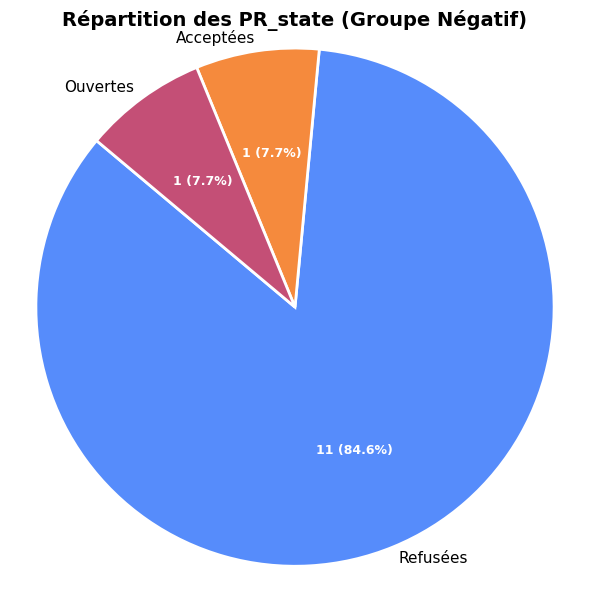

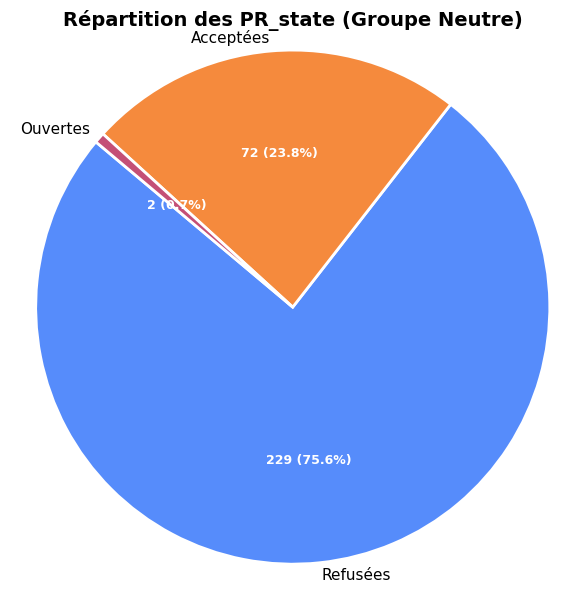

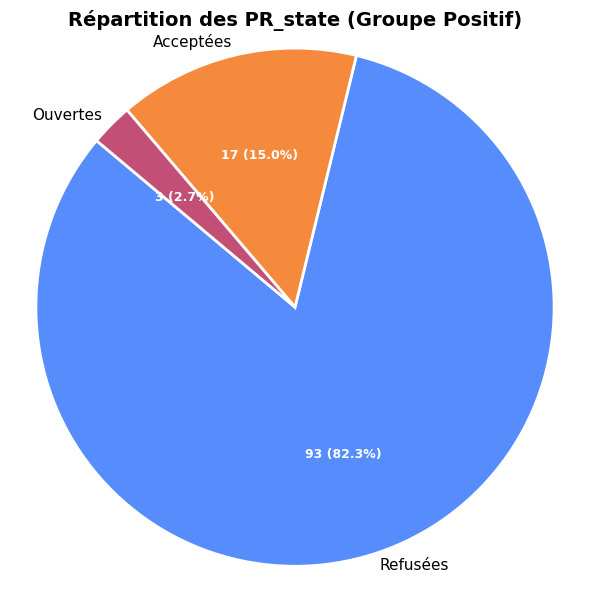

In [139]:

plot_pie(df_negative, "Répartition des PR_state (Groupe Négatif)")
plot_pie(df_neutral,  "Répartition des PR_state (Groupe Neutre)")
plot_pie(df_positive, "Répartition des PR_state (Groupe Positif)")


# Boxplot sur les sous groupes 

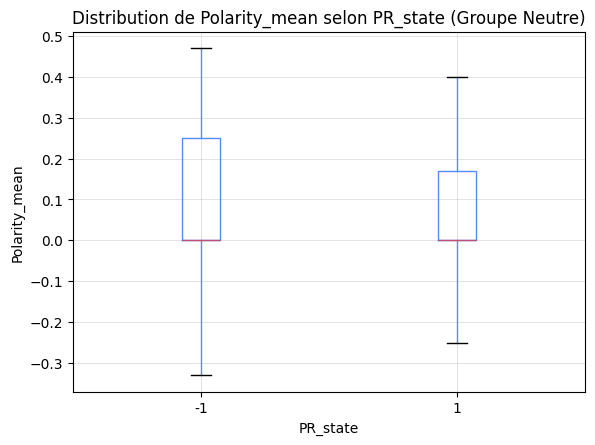

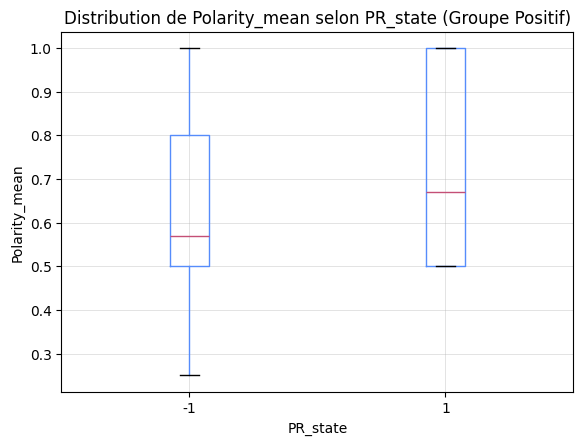

In [110]:


datasets = {
    "negative": df_negative,
    "neutral": df_neutral,
    "positive": df_positive
}

#df_negative.boxplot(column="Polarity_mean", by="PR_state")
#df_negative = df_negative.dropna(subset=["Polarity_mean", "PR_state"])
## Titres
#plt.title("Distribution de Polarity_mean selon PR_state (Groupe Négatif)")
#plt.suptitle("")  # enlève le titre automatique
#plt.xlabel("PR_state")
#plt.ylabel("Polarity_mean")




df_neutral = df_neutral.dropna(subset=["Polarity_mean", "PR_state"])
df_neutral_filtered = df_neutral[df_neutral["PR_state"].isin([-1, 1])]

df_neutral_filtered.boxplot(column="Polarity_mean", by="PR_state")

plt.title("Distribution de Polarity_mean selon PR_state (Groupe Neutre)")
plt.suptitle("")
plt.xlabel("PR_state")
plt.ylabel("Polarity_mean")

plt.show()




df_positive = df_positive.dropna(subset=["Polarity_mean", "PR_state"])
df_positive_filtered = df_positive[df_positive["PR_state"].isin([-1, 1])]

df_positive_filtered.boxplot(column="Polarity_mean", by="PR_state")

plt.title("Distribution de Polarity_mean selon PR_state (Groupe Positif)")
plt.suptitle("")
plt.xlabel("PR_state")
plt.ylabel("Polarity_mean")

plt.show()



# T-test groupe Neutre (entre PR refusées et acceptées)

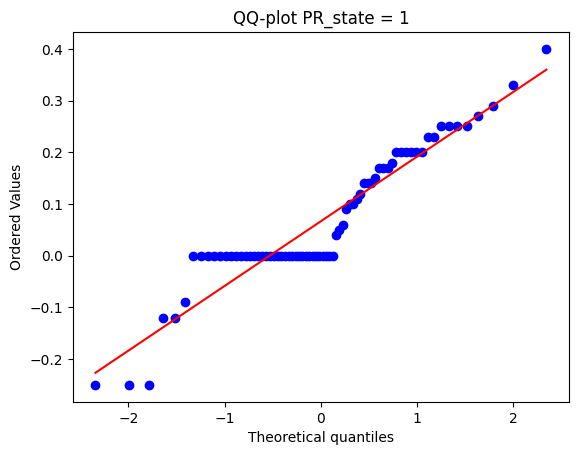

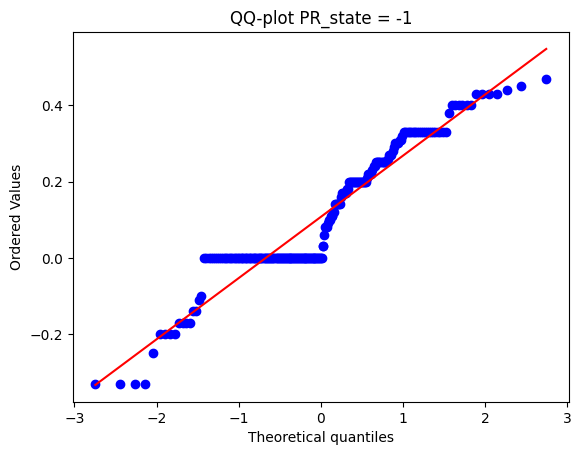

In [111]:
import scipy.stats as stats
group_1 = df_neutral[df_neutral["PR_state"] == 1]["Polarity_mean"].dropna()
group_minus1 = df_neutral[df_neutral["PR_state"] == -1]["Polarity_mean"].dropna()



# QQ plot groupe PR_state = 1
plt.figure()
stats.probplot(group_1, dist="norm", plot=plt)
plt.title("QQ-plot PR_state = 1")
plt.show()

# QQ plot groupe PR_state = -1
plt.figure()
stats.probplot(group_minus1, dist="norm", plot=plt)
plt.title("QQ-plot PR_state = -1")
plt.show()


# T-test bilatéral

In [112]:

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group_1, group_minus1, equal_var=False)  # Welch

print("t-stat :", t_stat)
print("p-value :", p_value)


t-stat : -2.158085967285433
p-value : 0.03249771595925786


# T-test groupe Positif (entre PR refusées et acceptées)

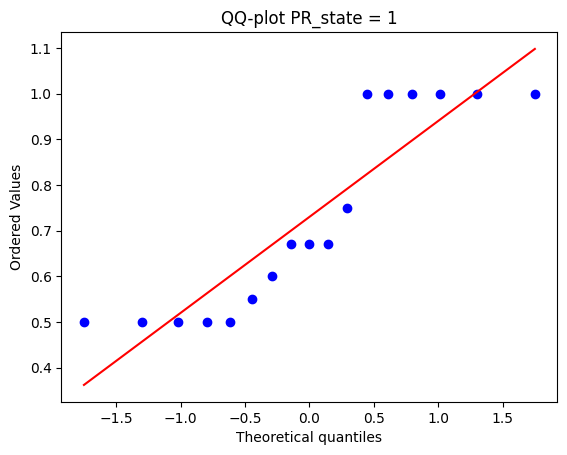

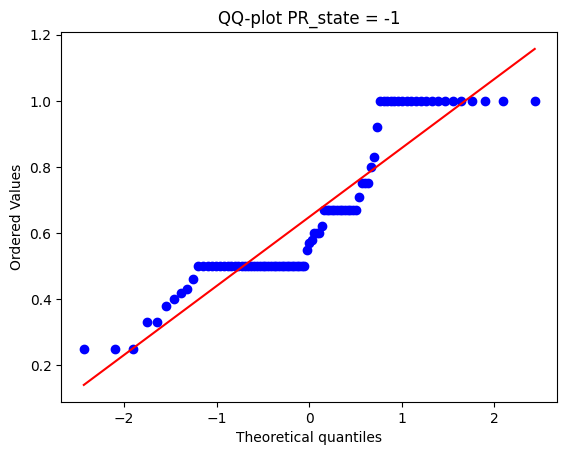

In [113]:
group_1 = df_positive[df_positive["PR_state"] == 1]["Polarity_mean"].dropna()
group_minus1 = df_positive[df_positive["PR_state"] == -1]["Polarity_mean"].dropna()



# QQ plot groupe PR_state = 1
plt.figure()
stats.probplot(group_1, dist="norm", plot=plt)
plt.title("QQ-plot PR_state = 1")
plt.show()

# QQ plot groupe PR_state = -1
plt.figure()
stats.probplot(group_minus1, dist="norm", plot=plt)
plt.title("QQ-plot PR_state = -1")
plt.show()

# T-test unilatéral

In [114]:

from scipy.stats import ttest_ind

t_stat, p_value_two_sided = ttest_ind(
    group_1,
    group_minus1,
    equal_var=False  # Welch
)

# ✅ Transformer en test unilatéral
if t_stat > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - (p_value_two_sided / 2)

print(group_1.mean(), group_minus1.mean())

print("t-stat:", t_stat)
print("p-value (unilatéral):", p_value_one_sided)


0.73 0.6488172043010753
t-stat: 1.40672583146665
p-value (unilatéral): 0.0866004495508358


# Corr matrix sur les sous groupes

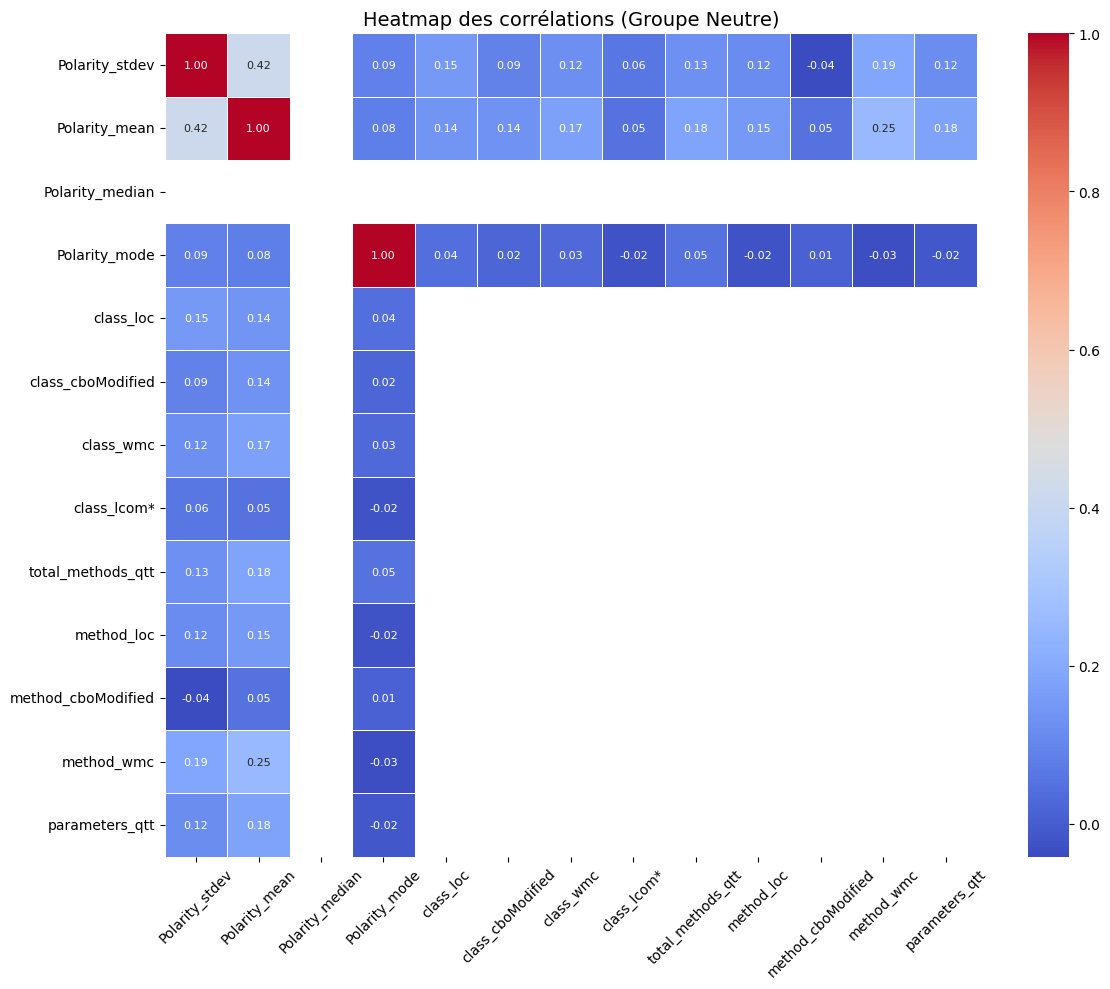

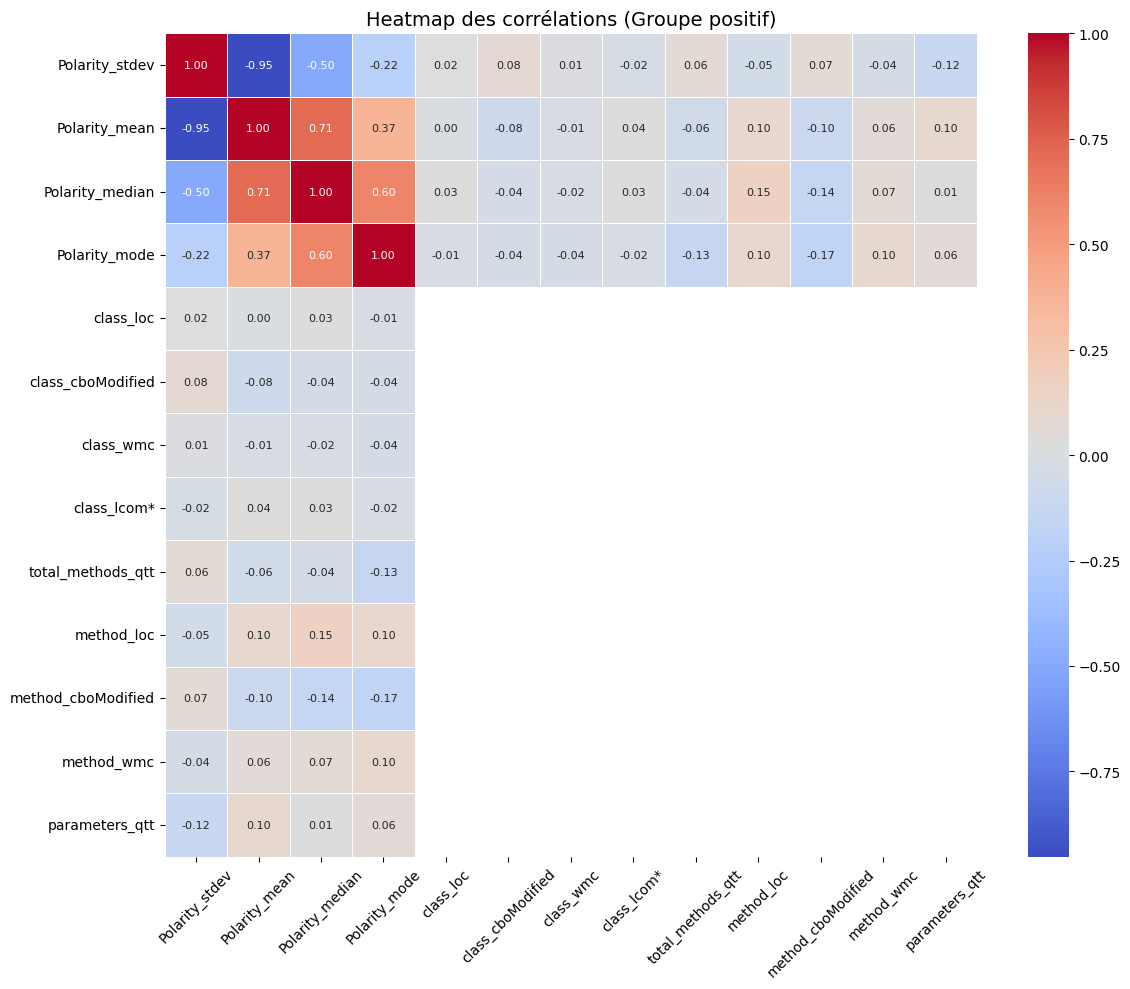

In [115]:

#cols = df_negative.loc[:, "class_loc":"parameters_qtt"].columns
#
## Ajouter Polarity_stdev
#data = df_negative[ ["Polarity_stdev", "Polarity_mean", "Polarity_median", "Polarity_mode"] + cols.tolist()]
#
## Calcul de la matrice de corrélation
#corr_matrix = data.corr(numeric_only=True, method='pearson')
#
## Affichage heatmap
#
#plt.figure(figsize=(12, 10))
#mask = np.zeros_like(corr_matrix, dtype=bool)
#mask[4:, 4:] = True
#sns.heatmap(
#    corr_matrix,
#    annot=True,
#    cmap="coolwarm",
#    mask = mask,
#    fmt=".2f",
#    linewidths=0.5,
#    annot_kws={"size": 8}
#)
#plt.title("Heatmap des corrélations (Groupe Négatif)", fontsize=14)
#plt.xticks(rotation=45)
#plt.yticks(rotation=0)
#
#plt.tight_layout()
#plt.show()
#
#-----------------------------------------

cols = df_neutral.loc[:, "class_loc":"parameters_qtt"].columns

# Ajouter Polarity_stdev
data = df_neutral[ ["Polarity_stdev", "Polarity_mean", "Polarity_median", "Polarity_mode"] + cols.tolist()]

# Calcul de la matrice de corrélation
corr_matrix = data.corr(numeric_only=True, method='pearson')

# Affichage heatmap

plt.figure(figsize=(12, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[4:, 4:] = True
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    mask = mask,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Heatmap des corrélations (Groupe Neutre)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#-------------------------------------------

cols = df_positive.loc[:, "class_loc":"parameters_qtt"].columns

# Ajouter Polarity_stdev
data = df_positive[ ["Polarity_stdev", "Polarity_mean", "Polarity_median", "Polarity_mode"] + cols.tolist()]

# Calcul de la matrice de corrélation
corr_matrix = data.corr(numeric_only=True, method='pearson')

# Affichage heatmap

plt.figure(figsize=(12, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[4:, 4:] = True
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    mask = mask,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Heatmap des corrélations (Groupe positif)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# Evolution de la valeur moyenne

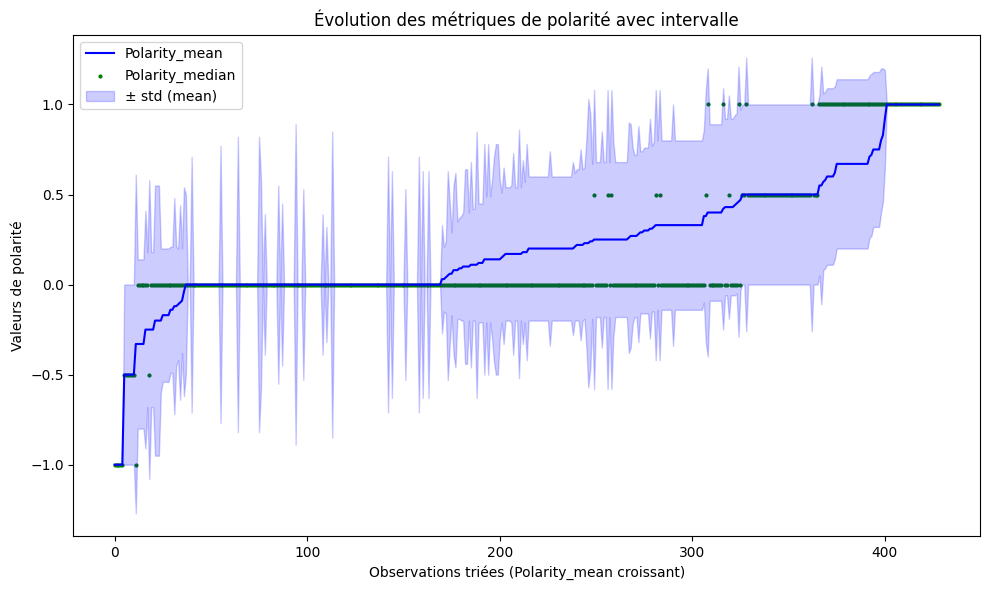

In [116]:

# Nettoyage
df = df.dropna(subset=["Polarity_mean", "Polarity_median", "Polarity_stdev"])

# Trier par Polarity_mean
df_sorted = df.sort_values(by="Polarity_mean")

# Extraire les valeurs
x = np.arange(len(df_sorted))  # index trié
mean = df_sorted["Polarity_mean"]
median = df_sorted["Polarity_median"]
std = df_sorted["Polarity_stdev"]

# Plot
plt.figure(figsize=(10, 6))

# Ligne moyenne
plt.plot(x, mean, label="Polarity_mean", color="blue")

# Ligne médiane
plt.scatter(x, median, label="Polarity_median", color="green", s = 4)

# Intervalle ± écart-type autour de la moyenne
plt.fill_between(
    x,
    mean - std,
    mean + std,
    color="blue",
    alpha=0.2,
    label="± std (mean)"
)

#n = len(df_sorted)
#ci = 1.96 * (std / np.sqrt(n))  # IC 95%
#
#plt.fill_between(
#    x,
#    mean - ci,
#    mean + ci,
#    color="blue",
#    alpha=0.3,
#    label="IC 95%"
#)

## Option : aussi autour de la médiane
#plt.fill_between(
#    x,
#    median - std,
#    median + std,
#    color="green",
#    alpha=0.1,
#    label="± std (median)"
#)

# Labels
plt.xlabel("Observations triées (Polarity_mean croissant)")
plt.ylabel("Valeurs de polarité")

plt.title("Évolution des métriques de polarité avec intervalle")
plt.legend()

plt.tight_layout()
plt.show()


# Avec intervale de confiance

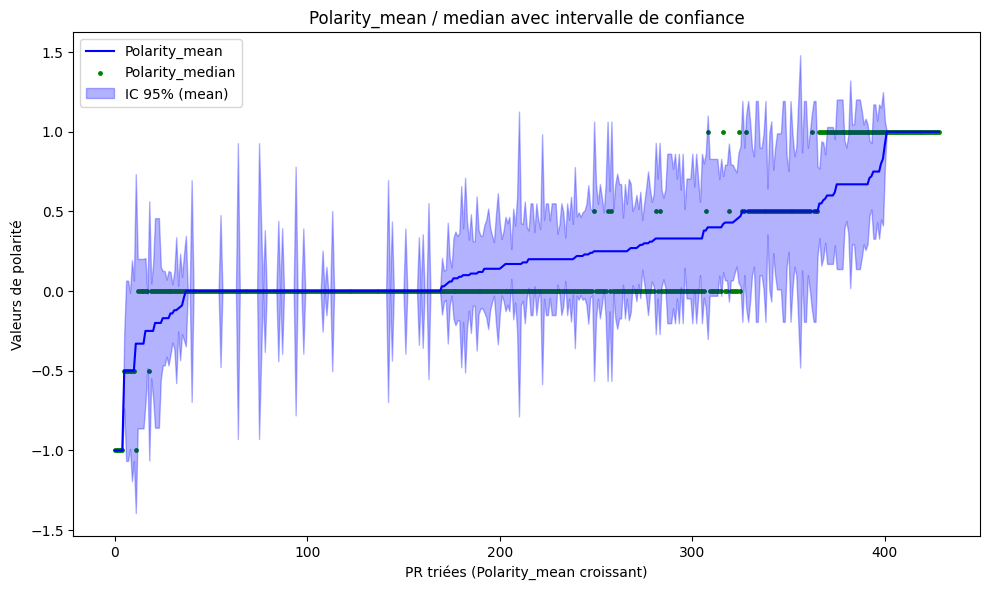

In [117]:



# Nettoyage
df = df.dropna(subset=[
    "Polarity_mean",
    "Polarity_median",
    "Polarity_stdev",
    "PR_nb_comments"
])

# Trier par mean
df_sorted = df.sort_values(by="Polarity_mean")

# Variables
x = np.arange(len(df_sorted))
mean = df_sorted["Polarity_mean"]
median = df_sorted["Polarity_median"]
std = df_sorted["Polarity_stdev"]
n = df_sorted["PR_nb_comments"]

# Calcul IC 95%
ci = 1.96 * (std / np.sqrt(n))

# Plot
plt.figure(figsize=(10, 6))

# Courbes
plt.plot(x, mean, label="Polarity_mean", color="blue")
plt.scatter(x, median, label="Polarity_median", color="green", s=6)

# Intervalle de confiance autour de la moyenne
plt.fill_between(
    x,
    mean - ci,
    mean + ci,
    color="blue",
    alpha=0.3,
    label="IC 95% (mean)"
)


# Labels
plt.xlabel("PR triées (Polarity_mean croissant)")
plt.ylabel("Valeurs de polarité")

plt.title("Polarity_mean / median avec intervalle de confiance")
plt.legend()

plt.tight_layout()
plt.show()


# Affichage des Outliers

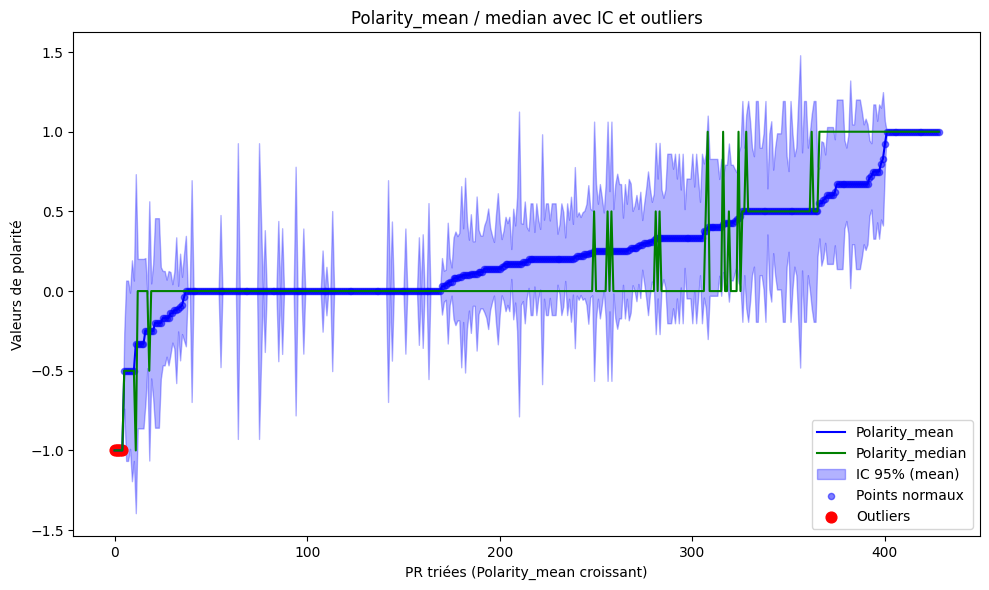

Nombre d'outliers : 5


In [118]:

# Trier
df_sorted = df.sort_values(by="Polarity_mean").reset_index(drop=True)

# Variables
x = np.arange(len(df_sorted))
mean = df_sorted["Polarity_mean"]
median = df_sorted["Polarity_median"]
std = df_sorted["Polarity_stdev"]
n = df_sorted["PR_nb_comments"]

# IC
ci = 1.96 * (std / np.sqrt(n))


# Détection des outliers (IQR sur Polarity_mean)
Q1 = mean.quantile(0.25)
Q3 = mean.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (mean < lower_bound) | (mean > upper_bound)


# ---------------------------
# Plot
# ---------------------------

plt.figure(figsize=(10, 6))

# Courbes principales
plt.plot(x, mean, label="Polarity_mean", color="blue")
plt.plot(x, median, label="Polarity_median", color="green")

# Intervalle de confiance
plt.fill_between(
    x,
    mean - ci,
    mean + ci,
    color="blue",
    alpha=0.3,
    label="IC 95% (mean)"
)

# ✅ Points normaux
plt.scatter(
    x[~outliers],
    mean[~outliers],
    color="blue",
    alpha=0.5,
    s=20,
    label="Points normaux"
)

# ✅ Outliers en rouge
plt.scatter(
    x[outliers],
    mean[outliers],
    color="red",
    s=60,
    label="Outliers"
)

# Labels
plt.xlabel("PR triées (Polarity_mean croissant)")
plt.ylabel("Valeurs de polarité")

plt.title("Polarity_mean / median avec IC et outliers")
plt.legend()

plt.tight_layout()
plt.show()

print("Nombre d'outliers :", outliers.sum())


# Evolution du Pourcentage de PR -1 et PR 1 en fct de la médiane

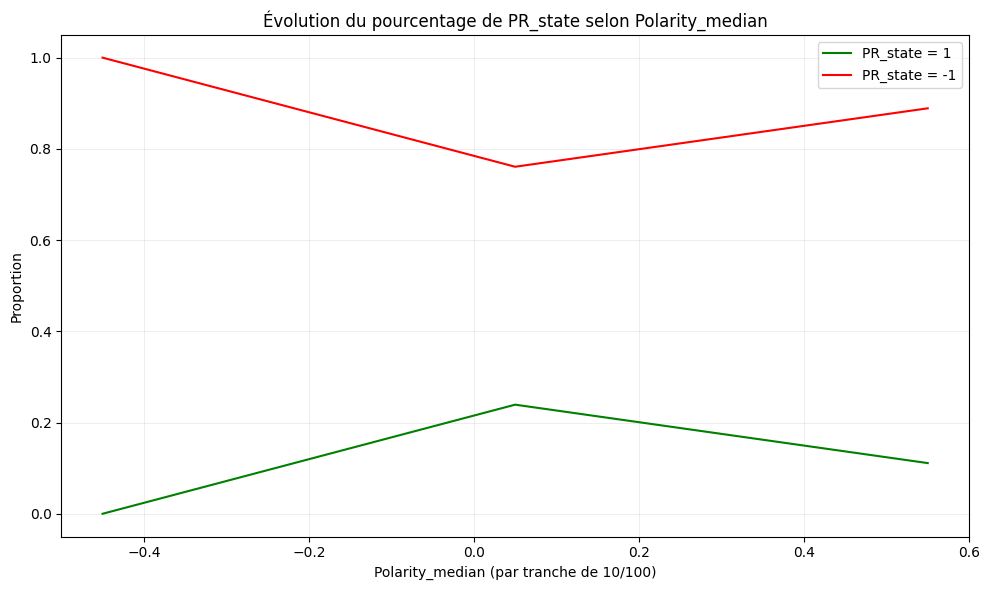

In [119]:

df_clean = df.dropna(subset=["Polarity_median", "PR_state"])
df_clean = df_clean[df_clean["PR_state"].isin([-1, 1])]



bins = np.arange(df_clean["Polarity_median"].min(),
                 df_clean["Polarity_median"].max(),
                 0.1)

df_clean["bin"] = pd.cut(df_clean["Polarity_median"], bins)



grouped = df_clean.groupby("bin")["PR_state"].value_counts(normalize=True)
grouped = grouped.unstack().fillna(0)

bin_centers = [interval.mid for interval in grouped.index]


plt.figure(figsize=(10, 6))

plt.plot(bin_centers, grouped[1], label="PR_state = 1", color="green")
plt.plot(bin_centers, grouped[-1], label="PR_state = -1", color="red")

plt.xlabel("Polarity_median (par tranche de 10/100)")
plt.ylabel("Proportion")

plt.title("Évolution du pourcentage de PR_state selon Polarity_median")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


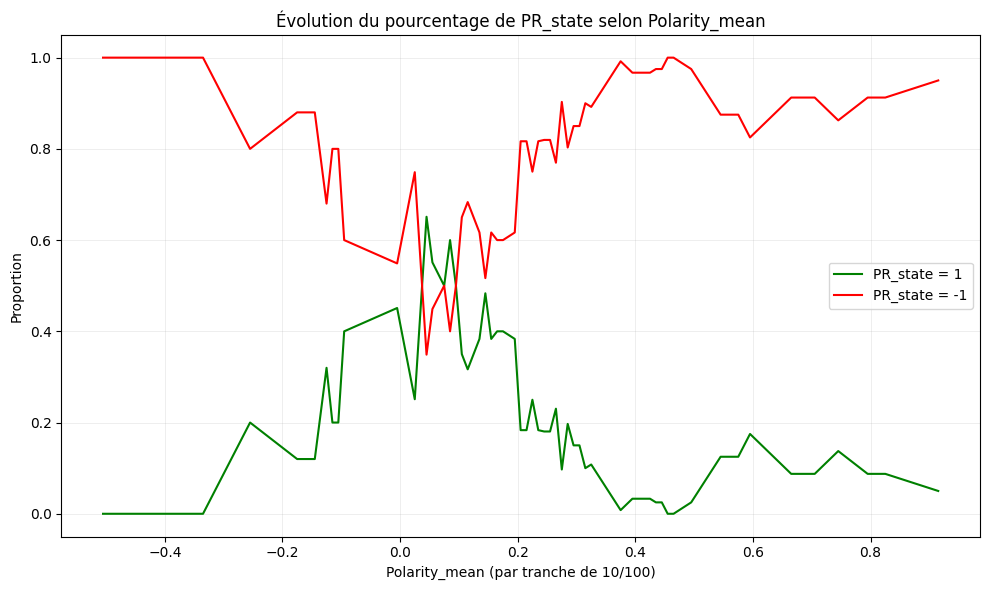

In [120]:

# ✅ nettoyage + filtrage
df_clean = df.dropna(subset=["Polarity_mean", "PR_state"])
df_clean = df_clean[df_clean["PR_state"].isin([-1, 1])]

# ✅ créer les bins (tranches)
bins = np.arange(
    df_clean["Polarity_mean"].min(),
    df_clean["Polarity_mean"].max(),
    0.01  # taille de tranche (à ajuster)
)

df_clean["bin"] = pd.cut(df_clean["Polarity_mean"], bins)

# ✅ calcul des proportions
grouped = df_clean.groupby("bin")["PR_state"].value_counts(normalize=True)
grouped = grouped.unstack().fillna(0)

# ✅ centres des bins
bin_centers = [interval.mid for interval in grouped.index]

# ✅ (optionnel) filtrer les bins peu remplis
counts = df_clean.groupby("bin").size()

bin_centers = np.array(bin_centers)

# ✅ (optionnel) lisser
grouped_smooth = grouped.rolling(window=5, min_periods=1).mean()

# ✅ plot
plt.figure(figsize=(10, 6))

plt.plot(bin_centers, grouped_smooth[1], label="PR_state = 1", color="green")
plt.plot(bin_centers, grouped_smooth[-1], label="PR_state = -1", color="red")

plt.xlabel("Polarity_mean (par tranche de 10/100)")
plt.ylabel("Proportion")

plt.title("Évolution du pourcentage de PR_state selon Polarity_mean")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Histogramme pour une PR

In [121]:

#numeric_cols = df.select_dtypes(include="number").columns
#
## Boucle sur chaque colonne
#for col in numeric_cols[1:]:
#    plt.figure()
#    
#    plt.hist(df[col].dropna(), bins=15, edgecolor="black")
#    
#    plt.title(f"Histogramme de {col}")
#    plt.xlabel(col)
#    plt.ylabel("Fréquence")
#    
#    plt.show()


In [122]:
#
#
##  Prendre UNE PR (par exemple la première)
#row = df.iloc[0]
#
## Sélectionner uniquement les métriques pertinentes
#cols = df.loc[:, "class_loc":"parameters_qtt"].columns
#
#values = row[cols].dropna().values
#
##  Histogramme
#plt.figure(figsize=(6, 4))
#
#plt.hist(values, bins=10, edgecolor="black")
#
#plt.title("Histogramme des métriques pour une PR")
#plt.xlabel("Valeurs des métriques")
#plt.ylabel("Nombre de métriques")
#
#plt.show()
#
#
#
#
#plt.hist(df["PR_nb_comments"].dropna(), bins=20, edgecolor="black")
#
#plt.title("Distribution du nombre de commentaires")
#plt.xlabel("Nombre de commentaires")
#plt.ylabel("Fréquence")
#
#plt.show()





# BOXPLOT

Text(0, 0.5, 'Polarity_mean')

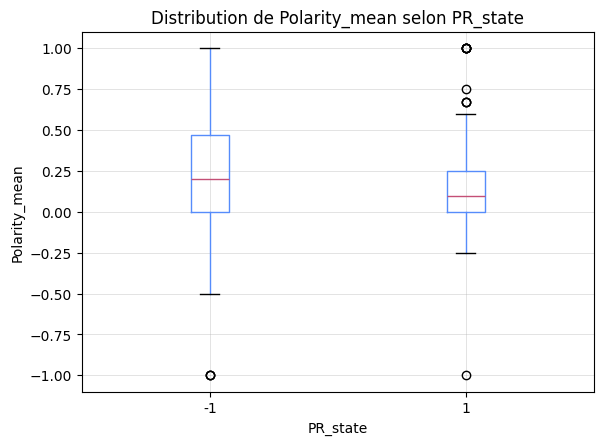

In [123]:
df = pd.read_csv(path)
df_filtered = df[df["PR_state"].isin([-1, 1])]

df_filtered.boxplot(column="Polarity_mean", by="PR_state")
df_filtered= df_filtered.dropna(subset=["Polarity_mean", "PR_state"])
# Titres
plt.title("Distribution de Polarity_mean selon PR_state")
plt.suptitle("")  # enlève le titre automatique
plt.xlabel("PR_state")
plt.ylabel("Polarity_mean")


Text(0, 0.5, 'Polarity_median')

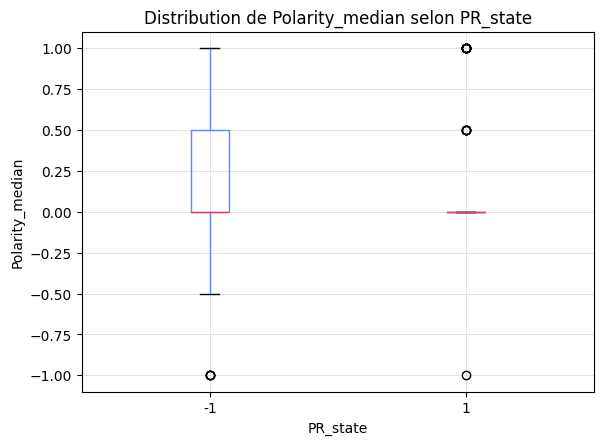

In [124]:
df = pd.read_csv(path)
df_filtered = df[df["PR_state"].isin([-1, 1])]

df_filtered.boxplot(column="Polarity_median", by="PR_state")
df_filtered= df_filtered.dropna(subset=["Polarity_median", "PR_state"])
# Titres
plt.title("Distribution de Polarity_median selon PR_state")
plt.suptitle("")  # enlève le titre automatique
plt.xlabel("PR_state")
plt.ylabel("Polarity_median")

# Scatter Plot

In [125]:

def make_scatter(df) : 
    # Nettoyage
    df = df.dropna(subset=["Polarity_stdev", "method_loc", "method_cboModified", "method_wmc", "parameters_qtt"])
    
    # Colonnes à analyser
    cols = df.loc[:, "class_loc":"parameters_qtt"].columns
    
    # Couleurs par PR_state
    colors = {
        -1: "red",
        0: "blue",
        1: "green"
    }
    
    for col in cols:
        x = df[col]
        y = df["Polarity_mean"]
        
        plt.figure()
        
        # Appliquer couleur selon PR_state
        for state, color in colors.items():
            subset = df[df["PR_state"] == state]
            
            plt.scatter(
                subset[col],
                subset["Polarity_mean"],
                color=color,
                alpha=0.5,
                label=f"PR_state = {state}"
            )
        
        plt.title(f"Polarity_mean vs {col}")
        plt.xlabel(col)
        plt.ylabel("Polarity_mean")
        
        # Ajouter légende
        plt.legend()
        
        plt.show()
    

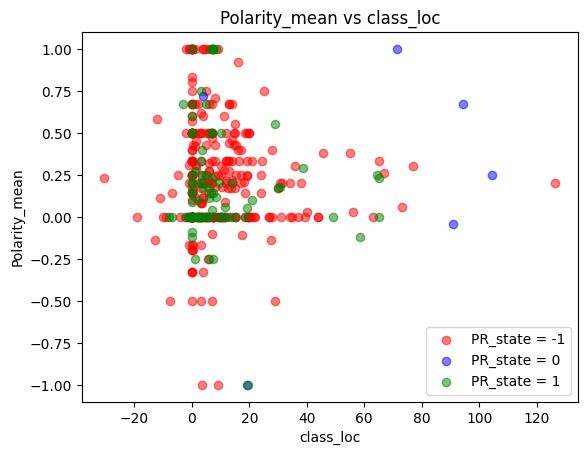

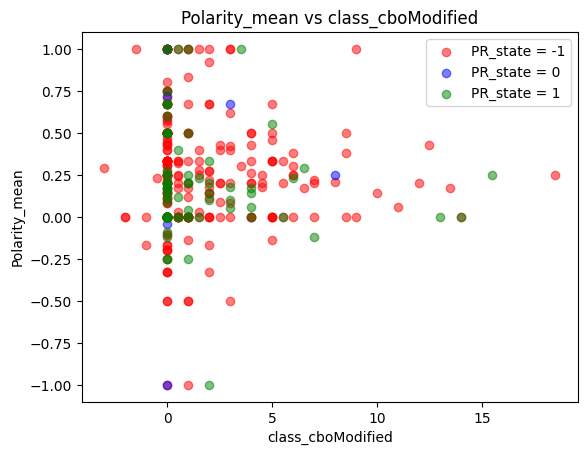

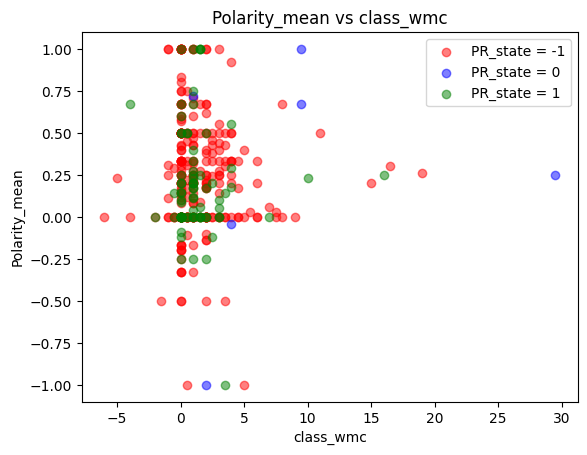

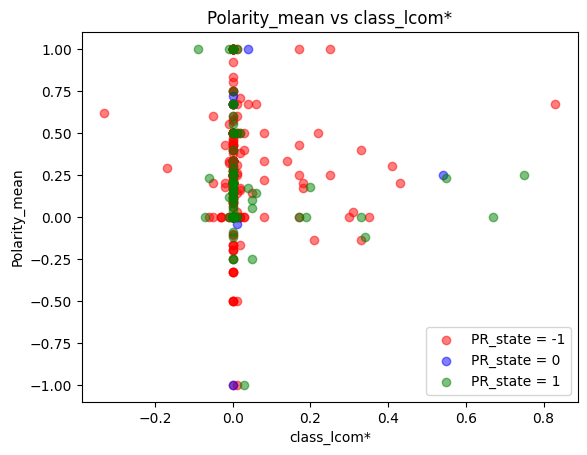

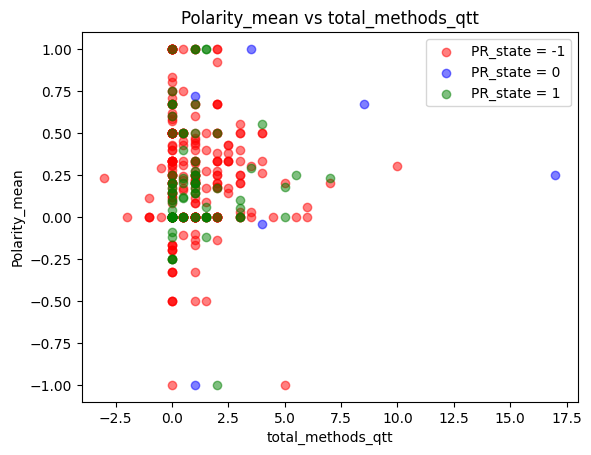

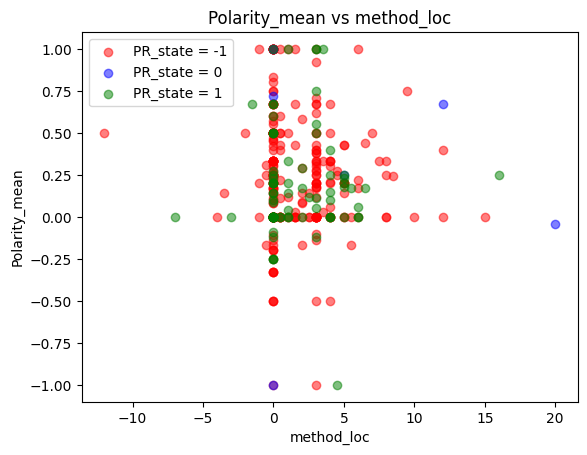

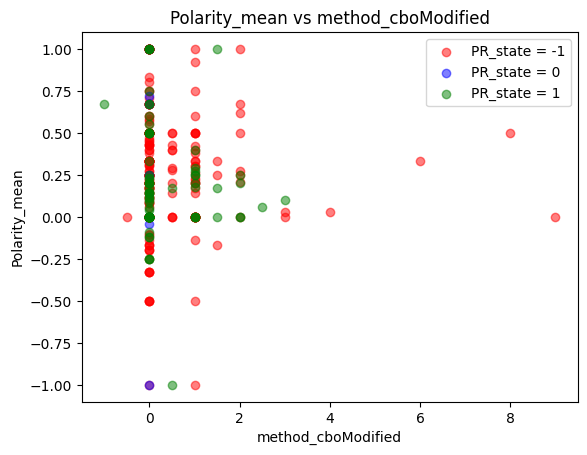

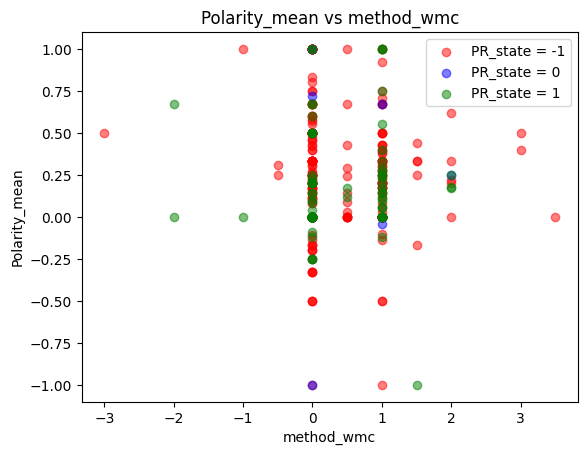

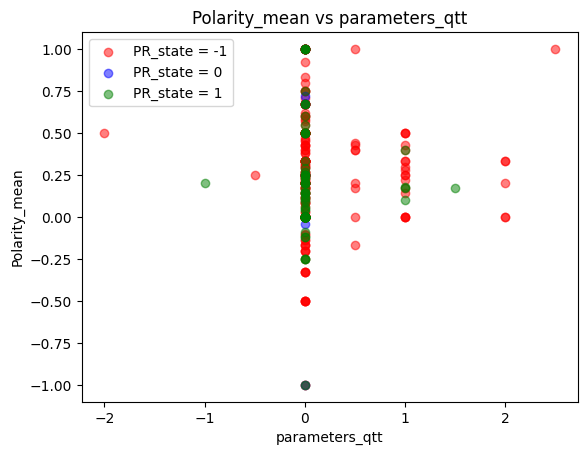

In [126]:
make_scatter(df)

# Scatter sur sous groupe neutre

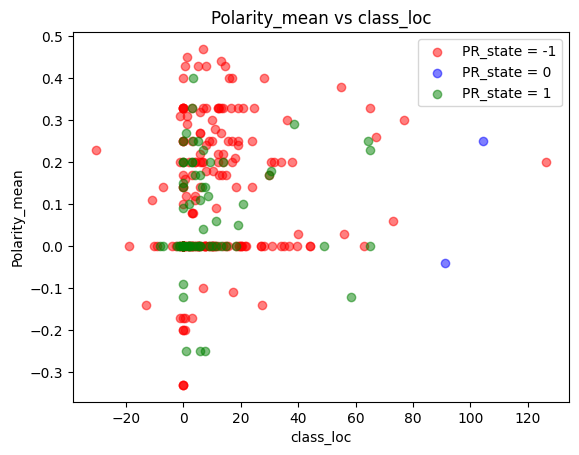

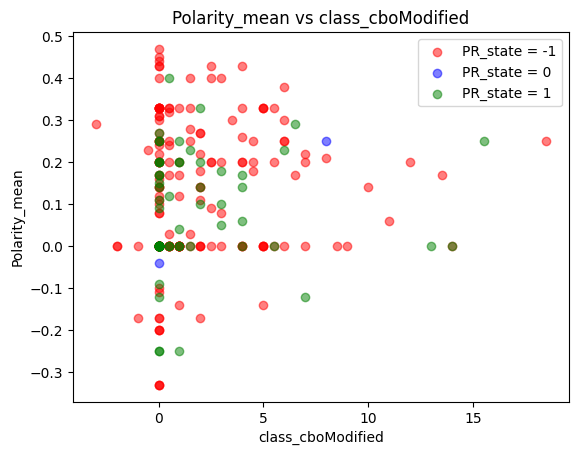

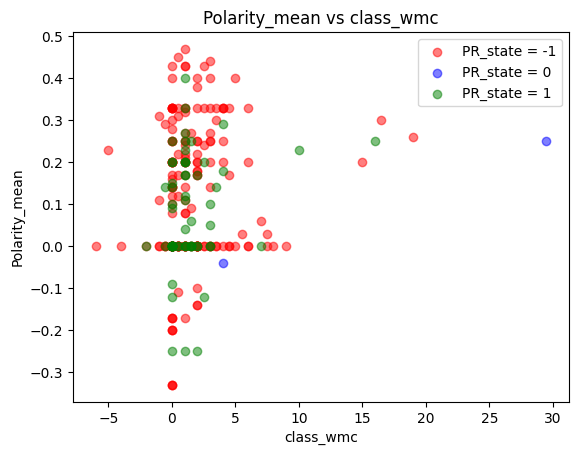

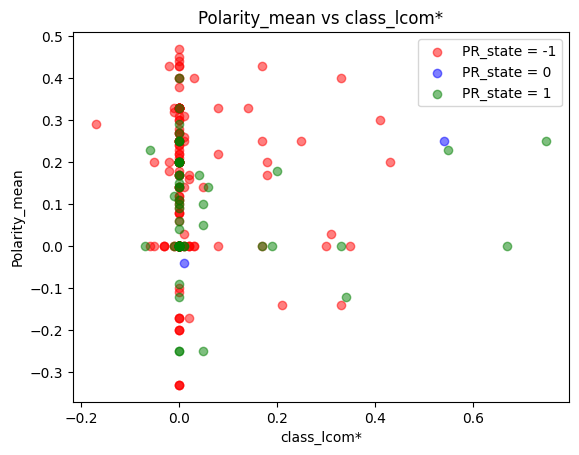

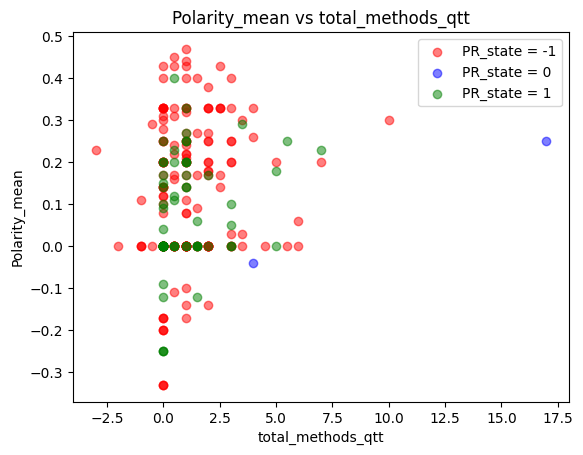

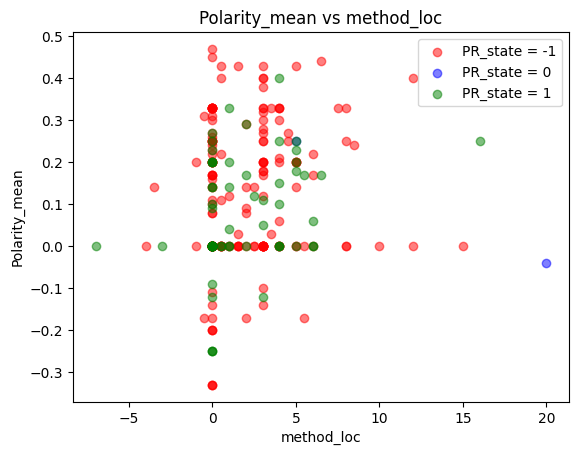

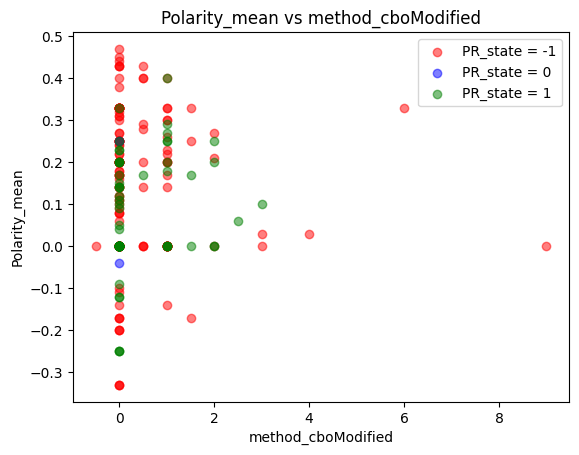

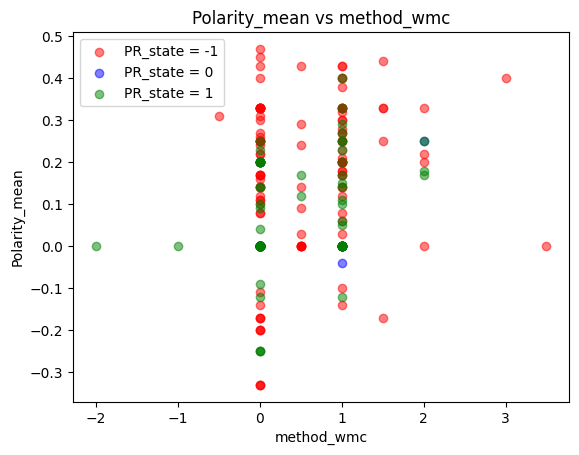

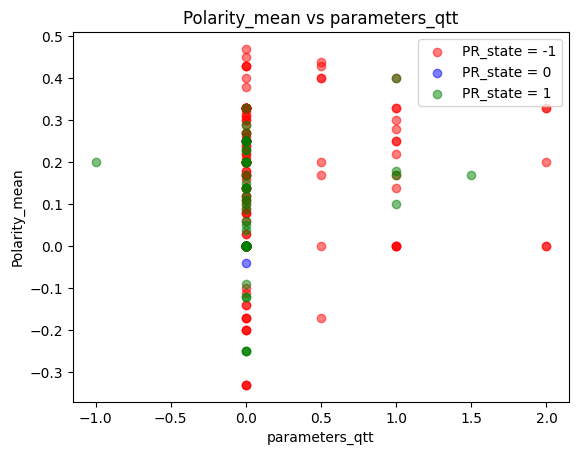

In [127]:
make_scatter(df_neutral)

# Scatter sur sous groupe positif

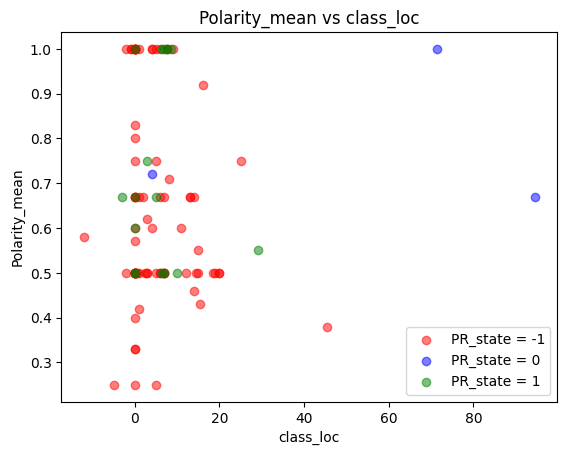

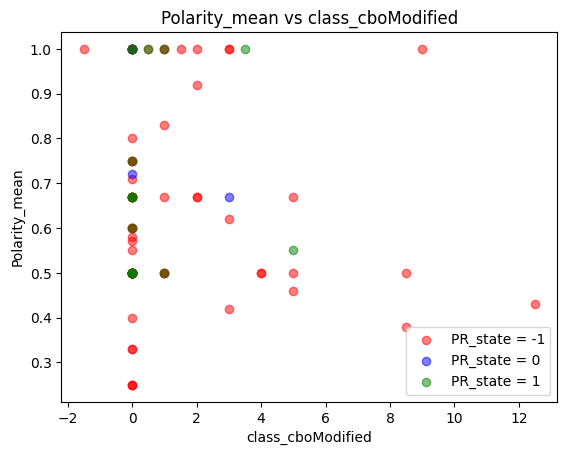

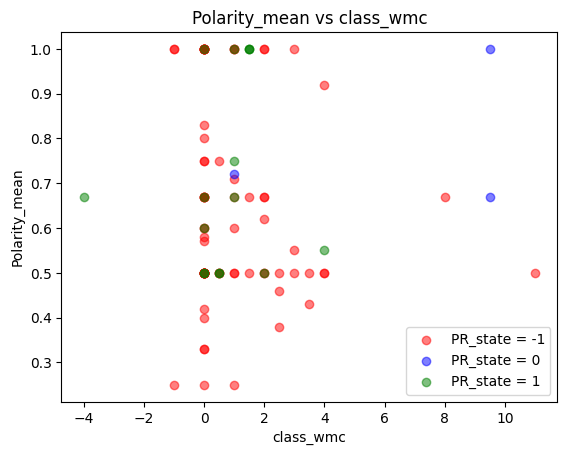

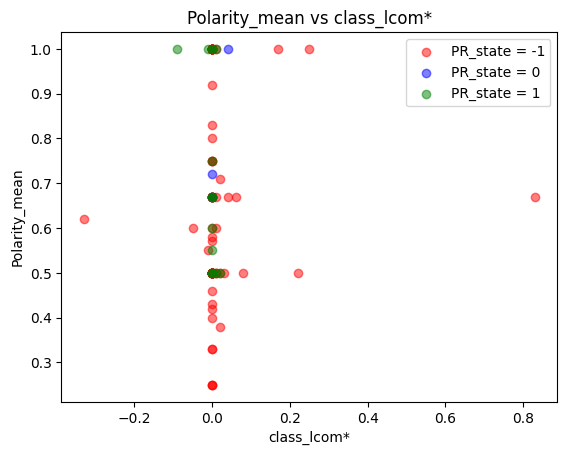

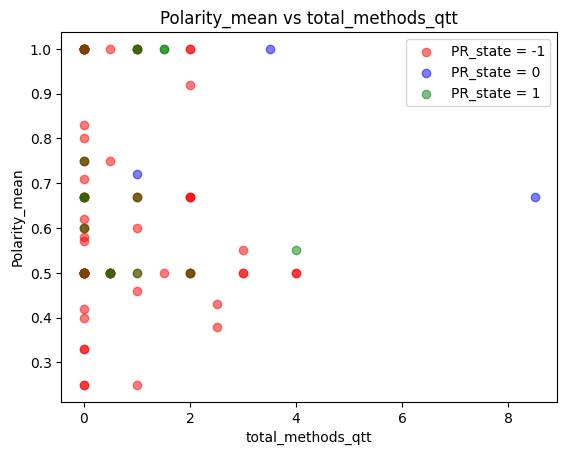

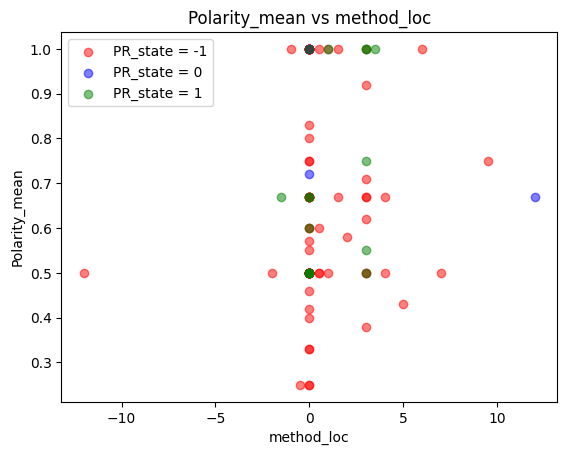

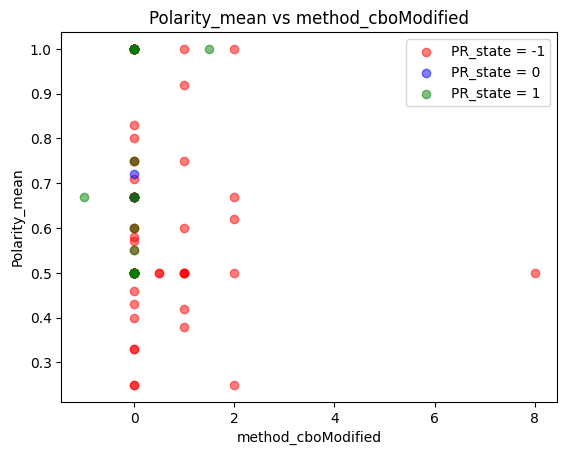

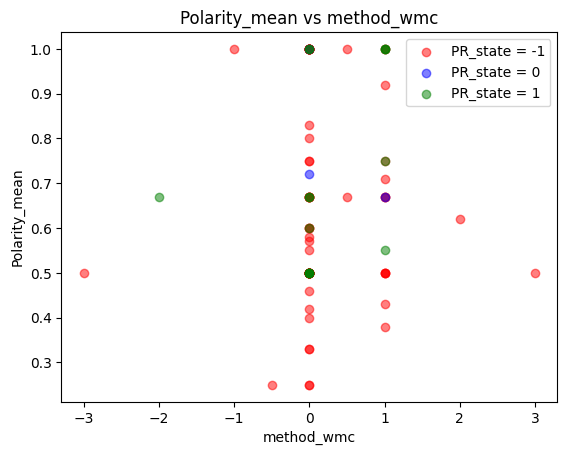

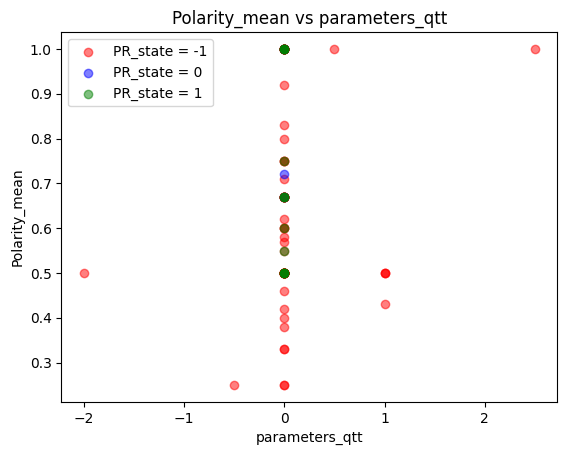

In [128]:
make_scatter(df_positive)

# Corr matrix 

In [129]:
# df_data = get_df_data(spring_security_path)
# df = pd.DataFrame(df_data)
#
# cols = df.loc[:, "class_loc":"parameters_qtt"].columns
#
# # Ajouter Polarity_stdev
# data = df[ ["Polarity_stdev", "Polarity_mean", "Polarity_median", "Polarity_mode"] + cols.tolist()]
#
# # Calcul de la matrice de corrélation
# corr_matrix = data.corr(numeric_only=True, method='pearson')
#
# # Affichage heatmap
#
# plt.figure(figsize=(12, 10))
# mask = np.zeros_like(corr_matrix, dtype=bool)
# mask[4:, 4:] = True
# sns.heatmap(
#     corr_matrix,
#     annot=True,
#     cmap="coolwarm",
#     mask = mask,
#     fmt=".2f",
#     linewidths=0.5,
#     annot_kws={"size": 8}
# )
#
#
#
#
# plt.title("Heatmap des corrélations", fontsize=14)
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
#
# plt.tight_layout()
# plt.show()


TypeError: 'Series' object is not callable

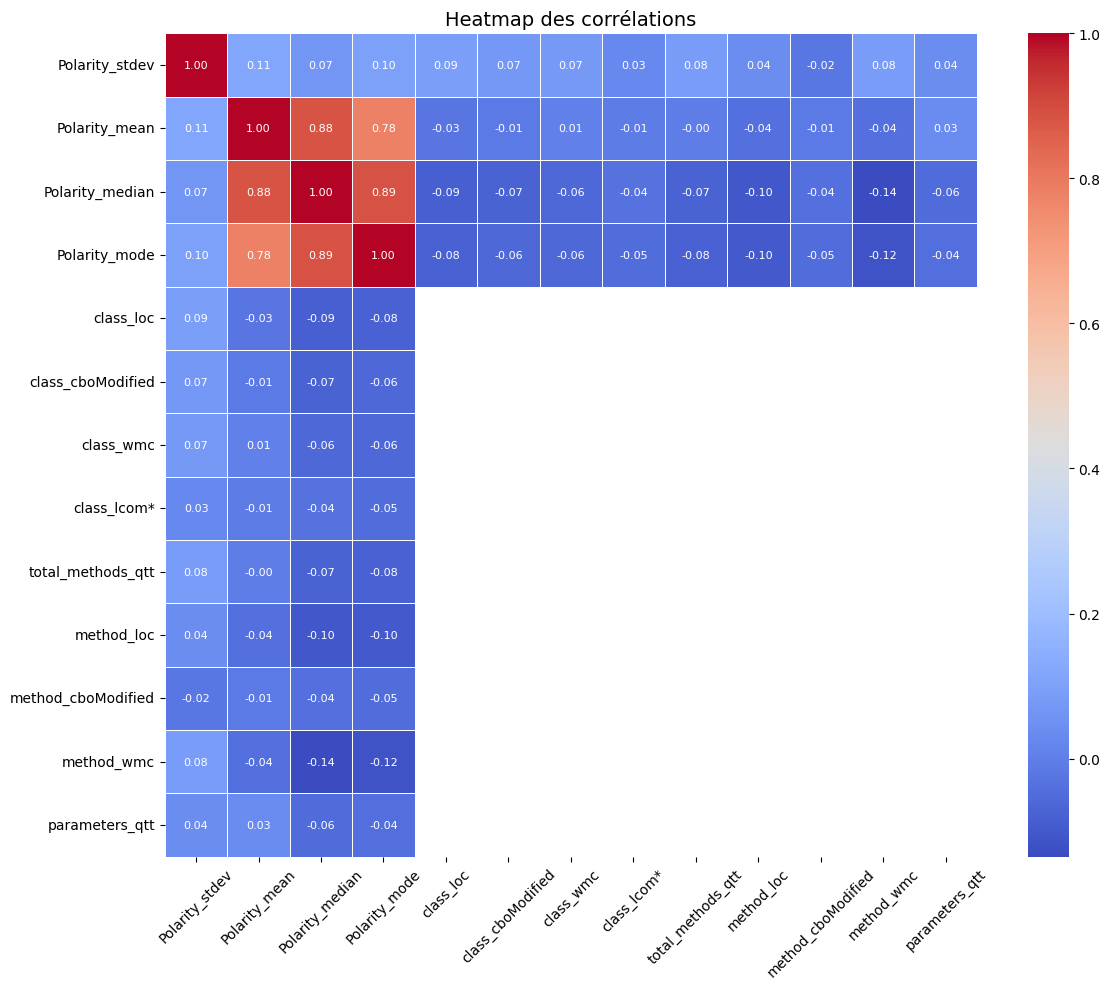

In [130]:

cols = df.loc[:, "class_loc":"parameters_qtt"].columns

# Ajouter Polarity_stdev
data = df[ ["Polarity_stdev", "Polarity_mean", "Polarity_median", "Polarity_mode"] + cols.tolist()]

# Calcul de la matrice de corrélation
corr_matrix = data.corr(numeric_only=True, method='pearson')

# Affichage heatmap

plt.figure(figsize=(12, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[4:, 4:] = True
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    mask = mask,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8}
)




plt.title("Heatmap des corrélations", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


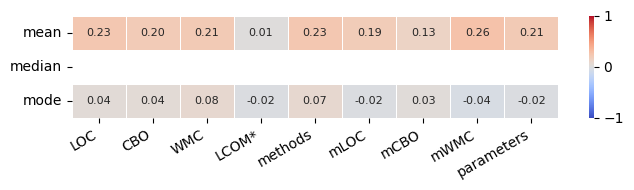

In [153]:
cols = df_neutral.loc[:, "class_loc":"parameters_qtt"].columns

# Ajouter Polarity_stdev
data = df_neutral[ ["Polarity_mean", "Polarity_median", "Polarity_mode"] + cols.tolist()]

# Calcul de la matrice de corrélation
corr_matrix = data.corr(numeric_only=True, method='spearman')

# Affichage heatmap

corr_display = corr_matrix.loc[["Polarity_mean", "Polarity_median", "Polarity_mode"],
    corr_matrix.columns[3:]]
plt.figure(figsize=(7, 2))
ax = sns.heatmap(
    corr_display,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 8}
)
#plt.title("Spearman's correlation (Neutral group)", fontsize=14)

nouveaux_labels = ["LOC", "CBO", "WMC", "LCOM*", "methods", "mLOC", "mCBO", "mWMC", "parameters"]
ax.set_xticklabels(nouveaux_labels, rotation=30, ha="right")

nouveaux_labels = ["mean", "median", "mode"]
ax.set_yticklabels(nouveaux_labels, rotation=0)
#plt.xticks(rotation=30, ha="right")
#plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


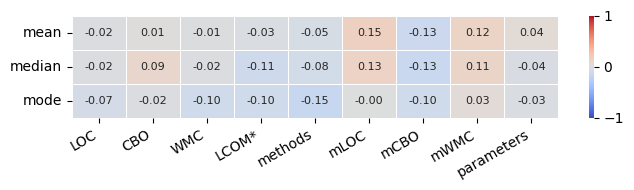

In [154]:
cols = df_positive.loc[:, "class_loc":"parameters_qtt"].columns

# Ajouter Polarity_stdev
data = df_positive[ ["Polarity_mean", "Polarity_median", "Polarity_mode"] + cols.tolist()]

# Calcul de la matrice de corrélation
corr_matrix = data.corr(numeric_only=True, method='spearman')

# Affichage heatmap

corr_display = corr_matrix.loc[["Polarity_mean", "Polarity_median", "Polarity_mode"],
    corr_matrix.columns[3:]]
plt.figure(figsize=(7, 2))
ax = sns.heatmap(
    corr_display,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8}
)
#plt.title("Spearman's correlation (Positive group)", fontsize=14)
nouveaux_labels = ["LOC", "CBO", "WMC", "LCOM*", "methods", "mLOC", "mCBO", "mWMC", "parameters"]
ax.set_xticklabels(nouveaux_labels, rotation=30, ha="right")

nouveaux_labels = ["mean", "median", "mode"]
ax.set_yticklabels(nouveaux_labels, rotation=0)
#plt.xticks(rotation=30, ha="right")
#plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

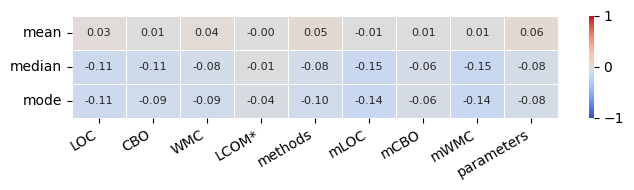

In [156]:
cols = df.loc[:, "class_loc":"parameters_qtt"].columns

# Ajouter Polarity_stdev
data = df[ ["Polarity_mean", "Polarity_median", "Polarity_mode"] + cols.tolist()]

# Calcul de la matrice de corrélation
corr_matrix = data.corr(numeric_only=True, method='spearman')

# Affichage heatmap

corr_display = corr_matrix.loc[["Polarity_mean", "Polarity_median", "Polarity_mode"],
    corr_matrix.columns[3:]]
plt.figure(figsize=(7, 2))
ax = sns.heatmap(
    corr_display,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8}
)
#plt.title("Spearman's correlation (all groups)", fontsize=14)
nouveaux_labels = ["LOC", "CBO", "WMC", "LCOM*", "methods", "mLOC", "mCBO", "mWMC", "parameters"]
ax.set_xticklabels(nouveaux_labels, rotation=30, ha="right")

nouveaux_labels = ["mean", "median", "mode"]
ax.set_yticklabels(nouveaux_labels, rotation=0)
#plt.xticks(rotation=30, ha="right")
#plt.yticks(rotation=0)

plt.tight_layout()
plt.show()